# Scatterplot Workflow v4 Implementation

This notebook implements the generation workflow described in `scatterplot_workflow_v4.md`.

Important implementation choices:

- Shape labels are inherited directly from the function-family table; no label is inferred from generated data.
- SNR and spread structure are metadata/control factors, not label dimensions.
- The notebook builds metadata first, then generates scatterplot realizations lazily by case and replicate. This avoids materializing the full dataset by default.
- The explicit parameter lists produce 298 shape configurations: 206 monotonic 0 TP (including positive and negative direction variants), 64 one-turning-point, 18 cubic two-turning-point, 9 complex multiple-turning-point, and 1 Null.
- All monotonic nonlinear families include both positive and negative direction versions (y → −y), with curvature labels correctly flipped.

In [14]:
from __future__ import annotations

import json
import math
import time
import os
from dataclasses import dataclass, asdict
from itertools import product
from pathlib import Path
from typing import Any, Callable

import numpy as np
import pandas as pd

# Keep matplotlib cache inside the workspace when plots are used.
os.environ.setdefault("MPLCONFIGDIR", str(Path(".matplotlib").resolve()))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:  # Allows this notebook's code cells to be smoke-tested as plain Python.
    display = print

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)


## Constants and Label Table

Labels are defined at the function-family level. Variant parameters are recorded as metadata only.


In [15]:
N_PER_CASE = 500
REPLICATES = 100
SIGNAL_VARIANCE_GRID_SIZE = 20_001

SNR_LEVELS = [0.1, 0.3, 0.5, 1, 2, 3, 5, 10, 20, 50, 100, math.inf]
SPREAD_PATTERNS = ["constant", "increasing", "decreasing", "middle_high"]
N_CLUSTERS_VALUES = [2, 3, 4, 5]
CLUSTER_OCCUPANCY = 0.4
CLUSTER_BACKGROUND_FRAC = 0.1
X_DISTRIBUTIONS = ["even", "left_dense", "right_dense", "center_dense"] + [f"clusters_{k}" for k in N_CLUSTERS_VALUES]

FAMILY_LABELS: dict[str, dict[str, Any]] = {
    "F01": {
        "family_name": "Linear positive",
        "equation_presentation": "y = ax + b, a > 0",
        "basic_label": "slope a",
        "direction": "positive",
        "linearity": "linear",
        "monotonicity": "monotonic",
        "curvature": "N/A",
        "special_shape": "none",
        "tp_number": "0",
    },
    "F02": {
        "family_name": "Linear negative",
        "equation_presentation": "y = ax + b, a < 0",
        "basic_label": "slope a",
        "direction": "negative",
        "linearity": "linear",
        "monotonicity": "monotonic",
        "curvature": "N/A",
        "special_shape": "none",
        "tp_number": "0",
    },
    "F03": {
        "family_name": "Power convex positive",
        "equation_presentation": "y = x^p, p > 1",
        "basic_label": "exponent p",
        "direction": "positive",
        "linearity": "nonlinear",
        "monotonicity": "monotonic",
        "curvature": "convex",
        "special_shape": "none",
        "tp_number": "0",
    },
    "F04": {
        "family_name": "Power convex negative",
        "equation_presentation": "y = -x^p, p > 1",
        "basic_label": "exponent p",
        "direction": "negative",
        "linearity": "nonlinear",
        "monotonicity": "monotonic",
        "curvature": "concave",
        "special_shape": "none",
        "tp_number": "0",
    },
    "F05": {
        "family_name": "Power concave positive",
        "equation_presentation": "y = x^p, 0 < p < 1",
        "basic_label": "exponent p",
        "direction": "positive",
        "linearity": "nonlinear",
        "monotonicity": "monotonic",
        "curvature": "concave",
        "special_shape": "none",
        "tp_number": "0",
    },
    "F06": {
        "family_name": "Power concave negative",
        "equation_presentation": "y = -x^p, 0 < p < 1",
        "basic_label": "exponent p",
        "direction": "negative",
        "linearity": "nonlinear",
        "monotonicity": "monotonic",
        "curvature": "convex",
        "special_shape": "none",
        "tp_number": "0",
    },
    "F07": {
        "family_name": "Saturation positive",
        "equation_presentation": "y = 1 - exp(-kx)",
        "basic_label": "rate k",
        "direction": "positive",
        "linearity": "nonlinear",
        "monotonicity": "monotonic",
        "curvature": "concave",
        "special_shape": "saturation",
        "tp_number": "0",
    },
    "F08": {
        "family_name": "Saturation negative",
        "equation_presentation": "y = -(1 - exp(-kx))",
        "basic_label": "rate k",
        "direction": "negative",
        "linearity": "nonlinear",
        "monotonicity": "monotonic",
        "curvature": "convex",
        "special_shape": "saturation",
        "tp_number": "0",
    },
    "F09": {
        "family_name": "Log positive",
        "equation_presentation": "y = log(1 + ax)",
        "basic_label": "scale a",
        "direction": "positive",
        "linearity": "nonlinear",
        "monotonicity": "monotonic",
        "curvature": "concave",
        "special_shape": "none",
        "tp_number": "0",
    },
    "F10": {
        "family_name": "Log negative",
        "equation_presentation": "y = -log(1 + ax)",
        "basic_label": "scale a",
        "direction": "negative",
        "linearity": "nonlinear",
        "monotonicity": "monotonic",
        "curvature": "convex",
        "special_shape": "none",
        "tp_number": "0",
    },
    "F11": {
        "family_name": "Exponential positive",
        "equation_presentation": "y = a^x",
        "basic_label": "base a, x range",
        "direction": "positive",
        "linearity": "nonlinear",
        "monotonicity": "monotonic",
        "curvature": "convex",
        "special_shape": "none",
        "tp_number": "0",
    },
    "F12": {
        "family_name": "Exponential negative",
        "equation_presentation": "y = -a^x",
        "basic_label": "base a, x range",
        "direction": "negative",
        "linearity": "nonlinear",
        "monotonicity": "monotonic",
        "curvature": "concave",
        "special_shape": "none",
        "tp_number": "0",
    },
    "F13": {
        "family_name": "S-curve positive",
        "equation_presentation": "logistic (increasing)",
        "basic_label": "steepness k, center c",
        "direction": "positive",
        "linearity": "nonlinear",
        "monotonicity": "monotonic",
        "curvature": "mixed",
        "special_shape": "S-curve",
        "tp_number": "0",
    },
    "F14": {
        "family_name": "S-curve negative",
        "equation_presentation": "logistic (decreasing)",
        "basic_label": "steepness k, center c",
        "direction": "negative",
        "linearity": "nonlinear",
        "monotonicity": "monotonic",
        "curvature": "mixed",
        "special_shape": "S-curve",
        "tp_number": "0",
    },
    "F15": {
        "family_name": "Threshold positive",
        "equation_presentation": "piecewise, b > a",
        "basic_label": "gap, width, position",
        "direction": "positive",
        "linearity": "nonlinear",
        "monotonicity": "monotonic",
        "curvature": "N/A",
        "special_shape": "threshold",
        "tp_number": "0",
    },
    "F16": {
        "family_name": "Threshold negative",
        "equation_presentation": "piecewise, b < a",
        "basic_label": "gap, width, position",
        "direction": "negative",
        "linearity": "nonlinear",
        "monotonicity": "monotonic",
        "curvature": "N/A",
        "special_shape": "threshold",
        "tp_number": "0",
    },
    "F17": {
        "family_name": "Quadratic peak (Inverted U-shape)",
        "equation_presentation": "y = -a(x-c)^2 + d",
        "basic_label": "curvature a, position c",
        "direction": "none / local",
        "linearity": "nonlinear",
        "monotonicity": "non-monotonic",
        "curvature": "N/A",
        "special_shape": "peak (Inverted U-shape)",
        "tp_number": "1",
    },
    "F18": {
        "family_name": "Quadratic valley (U-shape)",
        "equation_presentation": "y = a(x-c)^2 + d",
        "basic_label": "curvature a, position c",
        "direction": "none / local",
        "linearity": "nonlinear",
        "monotonicity": "non-monotonic",
        "curvature": "N/A",
        "special_shape": "valley (U-shape)",
        "tp_number": "1",
    },
    "F19": {
        "family_name": "Spike",
        "equation_presentation": "narrow peak",
        "basic_label": "width, position",
        "direction": "none / local",
        "linearity": "nonlinear",
        "monotonicity": "non-monotonic",
        "curvature": "N/A",
        "special_shape": "local peak",
        "tp_number": "1",
    },
    "F20": {
        "family_name": "L-shaped / narrow valley",
        "equation_presentation": "piecewise valley",
        "basic_label": "width, position",
        "direction": "none / local",
        "linearity": "nonlinear",
        "monotonicity": "non-monotonic",
        "curvature": "N/A",
        "special_shape": "local valley",
        "tp_number": "1",
    },
    "F21": {
        "family_name": "Cubic",
        "equation_presentation": "cubic polynomial",
        "basic_label": "roots, sign, spacing, type = M/W",
        "direction": "none / mixed",
        "linearity": "nonlinear",
        "monotonicity": "non-monotonic",
        "curvature": "mixed",
        "special_shape": "cubic / two-turning",
        "tp_number": "2",
    },
    "F22": {
        "family_name": "Complex non-monotonic functions",
        "equation_presentation": "Double Gaussian, oscillation, etc.",
        "basic_label": "shape-specific",
        "direction": "none / mixed",
        "linearity": "nonlinear",
        "monotonicity": "non-monotonic",
        "curvature": "mixed",
        "special_shape": "complex",
        "tp_number": "Multiple",
    },
    "Null": {
        "family_name": "No relationship",
        "equation_presentation": "noise only",
        "basic_label": "none",
        "direction": "N/A",
        "linearity": "N/A",
        "monotonicity": "N/A",
        "curvature": "N/A",
        "special_shape": "no relationship",
        "tp_number": "N/A",
    },
}

label_df = pd.DataFrame.from_dict(FAMILY_LABELS, orient="index").reset_index(names="family_id")
display(label_df)


,family_id,family_name,equation_presentation,basic_label,direction,linearity,monotonicity,curvature,special_shape,tp_number
0,F01,Linear positive,"y = ax + b, a > 0",slope a,positive,linear,monotonic,N/A,none,0
1,F02,Linear negative,"y = ax + b, a < 0",slope a,negative,linear,monotonic,N/A,none,0
2,F03,Power convex positive,"y = x^p, p > 1",exponent p,positive,nonlinear,monotonic,convex,none,0
3,F04,Power convex negative,"y = -x^p, p > 1",exponent p,negative,nonlinear,monotonic,concave,none,0
4,F05,Power concave positive,"y = x^p, 0 < p < 1",exponent p,positive,nonlinear,monotonic,concave,none,0
5,F06,Power concave negative,"y = -x^p, 0 < p < 1",exponent p,negative,nonlinear,monotonic,convex,none,0
6,F07,Saturation positive,y = 1 - exp(-kx),rate k,positive,nonlinear,monotonic,concave,saturation,0
7,F08,Saturation negative,y = -(1 - exp(-kx)),rate k,negative,nonlinear,monotonic,convex,saturation,0
8,F09,Log positive,y = log(1 + ax),scale a,positive,nonlinear,monotonic,concave,none,0
9,F10,Log negative,y = -log(1 + ax),scale a,negative,nonlinear,monotonic,convex,none,0


## Shape Configuration Library

`build_shape_configs()` expands the explicit parameter variants from the document into concrete shape configurations.


In [16]:
@dataclass(frozen=True)
class ShapeConfig:
    shape_config_id: int
    family_id: str
    variant_name: str
    params: dict[str, Any]

    @property
    def labels(self) -> dict[str, Any]:
        return FAMILY_LABELS[self.family_id]


def _add_config(configs: list[ShapeConfig], family_id: str, variant_name: str, **params: Any) -> None:
    configs.append(
        ShapeConfig(
            shape_config_id=len(configs) + 1,
            family_id=family_id,
            variant_name=variant_name,
            params=params,
        )
    )


def build_shape_configs() -> list[ShapeConfig]:
    configs: list[ShapeConfig] = []

    # F01/F02: Linear positive/negative.
    for slope_abs in [0.1, 0.3, 0.5, 1, 2, 5]:
        _add_config(configs, "F01", f"slope_{slope_abs:g}", slope=float(slope_abs), intercept=0.0)
        _add_config(configs, "F02", f"slope_-{slope_abs:g}", slope=-float(slope_abs), intercept=0.0)

    # F03/F04: Power convex positive/negative.
    for p in [1.5, 2, 3, 5]:
        _add_config(configs, "F03", f"p_{p:g}", p=float(p))
        _add_config(configs, "F04", f"p_{p:g}", p=float(p))

    # F05/F06: Power concave positive/negative.
    for p in [0.2, 0.3, 0.5, 0.7]:
        _add_config(configs, "F05", f"p_{p:g}", p=float(p))
        _add_config(configs, "F06", f"p_{p:g}", p=float(p))

    # F07/F08: Saturation positive/negative.
    for k in [0.5, 1, 2, 3, 5, 8, 10, 15, 20]:
        _add_config(configs, "F07", f"k_{k:g}", k=float(k))
        _add_config(configs, "F08", f"k_{k:g}", k=float(k))

    # F09/F10: Log positive/negative.
    for a in [1, 5, 10, 20, 50]:
        _add_config(configs, "F09", f"a_{a:g}", a=float(a))
        _add_config(configs, "F10", f"a_{a:g}", a=float(a))

    # F11/F12: Exponential positive/negative.
    for base, x_range in product([1.5, 2, 5, 10], [1, 3, 5]):
        _add_config(configs, "F11", f"base_{base:g}_range_{x_range:g}", base=float(base), x_range=float(x_range))
        _add_config(configs, "F12", f"base_{base:g}_range_{x_range:g}", base=float(base), x_range=float(x_range))

    # F13/F14: S-curve positive/negative.
    for k, c in product([5, 8, 12, 20, 30], [0.3, 0.5, 0.7]):
        _add_config(configs, "F13", f"k_{k:g}_c_{c:g}", k=float(k), c=float(c), L1=0.0, L2=1.0)
        _add_config(configs, "F14", f"k_{k:g}_c_{c:g}", k=float(k), c=float(c), L1=0.0, L2=1.0)

    # F15/F16: Threshold positive/negative.
    for gap, delta, c in product([0.3, 0.5, 1, 2], [0.005, 0.01, 0.03, 0.05], [0.3, 0.5, 0.7]):
        _add_config(configs, "F15", f"gap_{gap:g}_delta_{delta:g}_c_{c:g}", a=0.0, b=float(gap), delta=float(delta), c=float(c))
        _add_config(configs, "F16", f"gap_{gap:g}_delta_{delta:g}_c_{c:g}", a=0.0, b=float(gap), delta=float(delta), c=float(c))

    # F17/F18: Quadratic peak/valley.
    for curvature, c in product([1, 4, 10, 20], [0.2, 0.35, 0.5, 0.65, 0.8]):
        _add_config(configs, "F17", f"a_{curvature:g}_c_{c:g}", a=float(curvature), c=float(c), d=0.0)
        _add_config(configs, "F18", f"a_{curvature:g}_c_{c:g}", a=float(curvature), c=float(c), d=0.0)

    # F19/F20: Spike / L-shaped (narrow local peak/valley).
    for width, c in product([0.02, 0.05, 0.1, 0.2], [0.3, 0.5, 0.7]):
        _add_config(configs, "F19", f"width_{width:g}_c_{c:g}", width=float(width), c=float(c))
        _add_config(configs, "F20", f"width_{width:g}_c_{c:g}", width=float(width), c=float(c))

    # F21: Cubic / two-turning shapes.
    cubic_positions = {"left": 0.35, "center": 0.5, "right": 0.65}
    cubic_spacings = {
        "narrow": {"half_width": 0.15, "a_abs": 30.0},
        "medium": {"half_width": 0.25, "a_abs": 18.0},
        "wide": {"half_width": 0.35, "a_abs": 10.0},
    }
    cubic_types = {"m": 1.0, "w": -1.0}
    for type_name, sign in cubic_types.items():
        for position_name, center in cubic_positions.items():
            for spacing_name, spacing_params in cubic_spacings.items():
                half_width = spacing_params["half_width"]
                roots = [center - half_width, center, center + half_width]
                _add_config(
                    configs,
                    "F21",
                    f"cubic_{type_name}_{position_name}_{spacing_name}",
                    roots=[float(r) for r in roots],
                    a=float(sign * spacing_params["a_abs"]),
                    d=0.0,
                    cubic_type="M" if type_name == "m" else "W",
                    position=position_name,
                    spacing=spacing_name,
                )

    # F22: Complex non-monotonic pool.
    complex_variants = [
        ("double_gaussian_equal", {"A1": 1.0, "mu1": 0.3, "sigma1": 0.08, "A2": 1.0, "mu2": 0.7, "sigma2": 0.08}),
        ("double_gaussian_unequal", {"A1": 1.0, "mu1": 0.3, "sigma1": 0.07, "A2": 0.55, "mu2": 0.72, "sigma2": 0.11}),
        ("pure_osc_low", {"A": 1.0, "omega": 2 * math.pi}),
        ("pure_osc_high", {"A": 1.0, "omega": 8 * math.pi}),
        ("oscillation_trend_weak", {"b": 0.4, "A": 0.4, "omega": 4 * math.pi}),
        ("oscillation_trend_strong", {"b": 1.2, "A": 0.25, "omega": 4 * math.pi}),
        ("damped_oscillation", {"A": 1.0, "lambda": 2.0, "omega": 8 * math.pi}),
        ("growing_oscillation", {"A": 0.25, "lambda": 2.0, "omega": 8 * math.pi}),
        ("varying_frequency", {"A": 1.0, "omega": 6 * math.pi}),
    ]
    for name, params in complex_variants:
        _add_config(configs, "F22", name, **params)

    # Null: 4 noise distributions, all standardized to mean=0, variance=1.
    _add_config(configs, "Null", "independent_normal", noise_dist="normal")
    _add_config(configs, "Null", "independent_uniform", noise_dist="uniform")
    _add_config(configs, "Null", "independent_heavy_tail", noise_dist="heavy_tail")
    _add_config(configs, "Null", "independent_skewed", noise_dist="skewed")
    return configs


shape_configs = build_shape_configs()
shape_df = pd.DataFrame([
    {
        **asdict(cfg),
        **cfg.labels,
        "params_json": json.dumps(cfg.params, sort_keys=True),
    }
    for cfg in shape_configs
]).drop(columns=["params"])

display(shape_df.head())
display(shape_df.groupby("family_id", sort=False).size().rename("n_configs").reset_index())
print(f"Shape configs from explicit parameter table: {len(shape_configs)}")

,shape_config_id,family_id,variant_name,family_name,equation_presentation,basic_label,direction,linearity,monotonicity,curvature,special_shape,tp_number,params_json
0,1,F01,slope_0.1,Linear positive,"y = ax + b, a > 0",slope a,positive,linear,monotonic,N/A,none,0,"{""intercept"": 0.0, ""slope"": 0.1}"
1,2,F02,slope_-0.1,Linear negative,"y = ax + b, a < 0",slope a,negative,linear,monotonic,N/A,none,0,"{""intercept"": 0.0, ""slope"": -0.1}"
2,3,F01,slope_0.3,Linear positive,"y = ax + b, a > 0",slope a,positive,linear,monotonic,N/A,none,0,"{""intercept"": 0.0, ""slope"": 0.3}"
3,4,F02,slope_-0.3,Linear negative,"y = ax + b, a < 0",slope a,negative,linear,monotonic,N/A,none,0,"{""intercept"": 0.0, ""slope"": -0.3}"
4,5,F01,slope_0.5,Linear positive,"y = ax + b, a > 0",slope a,positive,linear,monotonic,N/A,none,0,"{""intercept"": 0.0, ""slope"": 0.5}"


,family_id,n_configs
0,F01,6
1,F02,6
2,F03,4
3,F04,4
4,F05,4
5,F06,4
6,F07,9
7,F08,9
8,F09,5
9,F10,5


Shape configs from explicit parameter table: 301


## Function Evaluation

The evaluator maps normalized `x` values in `[0, 1]` to noiseless signal values `f(x)` for a selected `ShapeConfig`.


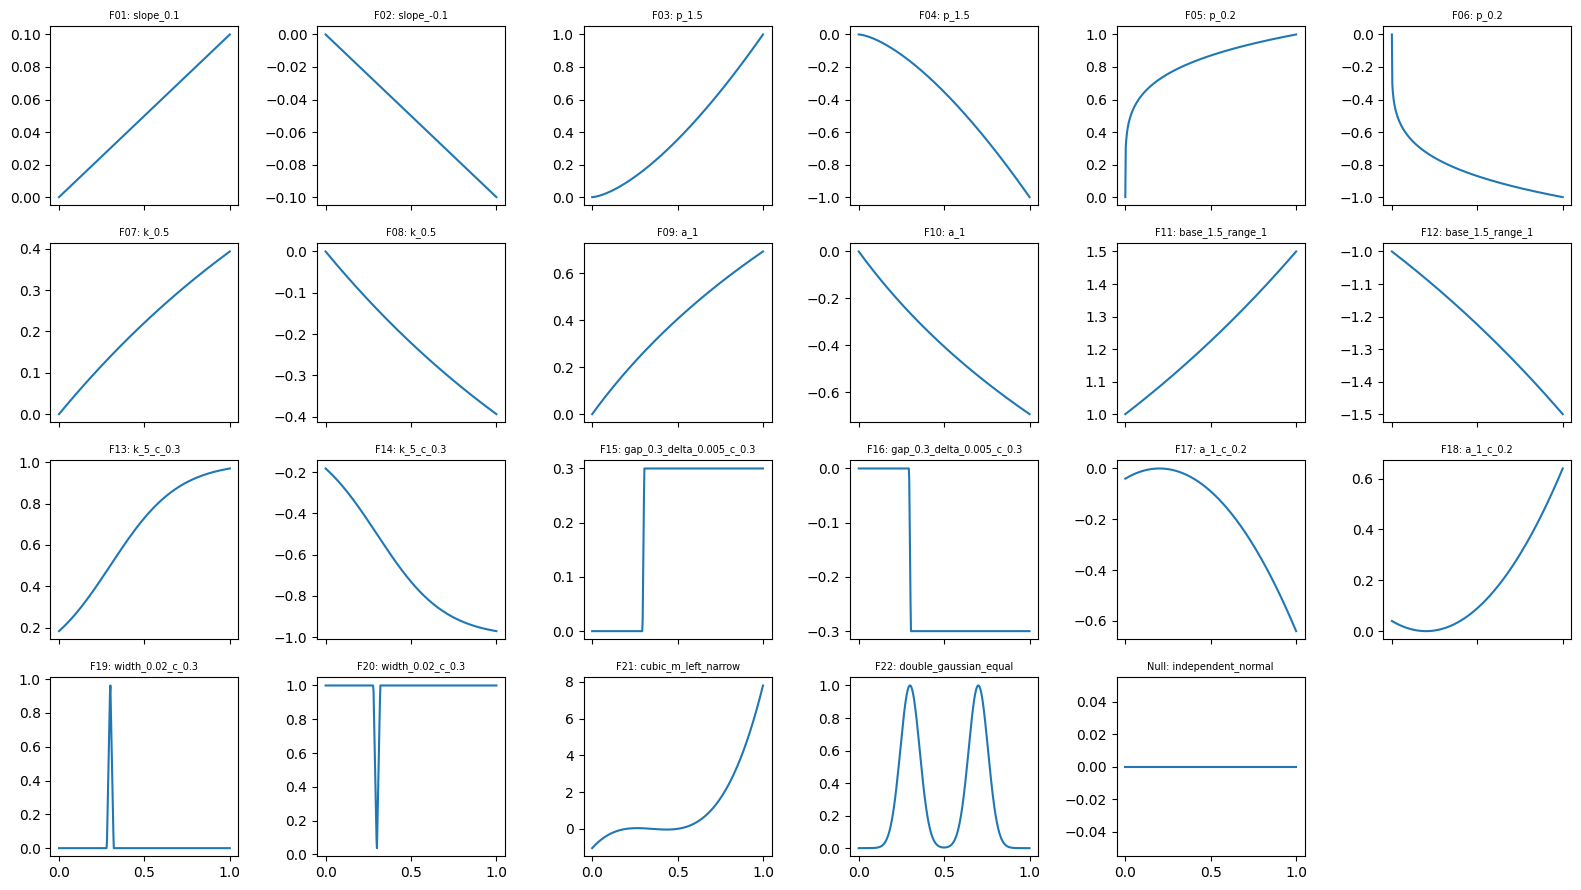

In [17]:
_NEGATIVE_COUNTERPART = {
    "F04": "F03", "F06": "F05", "F08": "F07", "F10": "F09",
    "F12": "F11", "F14": "F13", "F16": "F15",
}


def _triangular_local(x: np.ndarray, center: float, width: float) -> np.ndarray:
    return np.maximum(0.0, 1.0 - np.abs(x - center) / width)


def evaluate_signal(x: np.ndarray, cfg: ShapeConfig) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    p = cfg.params
    fid = cfg.family_id

    # Negative direction families: evaluate the positive counterpart and negate.
    if fid in _NEGATIVE_COUNTERPART:
        positive_cfg = ShapeConfig(
            shape_config_id=cfg.shape_config_id,
            family_id=_NEGATIVE_COUNTERPART[fid],
            variant_name=cfg.variant_name,
            params=cfg.params,
        )
        return -evaluate_signal(x, positive_cfg)

    if fid in {"F01", "F02"}:
        return p["slope"] * x + p.get("intercept", 0.0)
    if fid in {"F03", "F05"}:
        return x ** p["p"]
    if fid == "F07":
        return 1.0 - np.exp(-p["k"] * x)
    if fid == "F09":
        return np.log1p(p["a"] * x)
    if fid == "F11":
        return p["base"] ** (x * p["x_range"])
    if fid == "F13":
        return p["L1"] + (p["L2"] - p["L1"]) / (1.0 + np.exp(-p["k"] * (x - p["c"])))
    if fid == "F15":
        transition_fraction = np.clip((x - (p["c"] - p["delta"])) / (2.0 * p["delta"]), 0.0, 1.0)
        return p["a"] + (p["b"] - p["a"]) * transition_fraction
    if fid == "F17":
        return -p["a"] * (x - p["c"]) ** 2 + p["d"]
    if fid == "F18":
        return p["a"] * (x - p["c"]) ** 2 + p["d"]
    if fid == "F19":
        return _triangular_local(x, p["c"], p["width"])
    if fid == "F20":
        return 1.0 - _triangular_local(x, p["c"], p["width"])
    if fid == "F21":
        r1, r2, r3 = p["roots"]
        return p["a"] * (x - r1) * (x - r2) * (x - r3) + p["d"]
    if fid == "F22":
        name = cfg.variant_name
        if name.startswith("double_gaussian"):
            return (
                p["A1"] * np.exp(-((x - p["mu1"]) ** 2) / (p["sigma1"] ** 2))
                + p["A2"] * np.exp(-((x - p["mu2"]) ** 2) / (p["sigma2"] ** 2))
            )
        if name.startswith("pure_osc"):
            return p["A"] * np.sin(p["omega"] * x)
        if name.startswith("oscillation_trend"):
            return p["b"] * x + p["A"] * np.sin(p["omega"] * x)
        if name == "damped_oscillation":
            return p["A"] * np.exp(-p["lambda"] * x) * np.sin(p["omega"] * x)
        if name == "growing_oscillation":
            return p["A"] * np.exp(p["lambda"] * x) * np.sin(p["omega"] * x)
        if name == "varying_frequency":
            return p["A"] * np.sin(p["omega"] * x * (1.0 + x))
        raise ValueError(f"Unknown F22 variant: {name}")
    if fid == "Null":
        return np.zeros_like(x, dtype=float)

    raise ValueError(f"Unknown family_id: {fid}")


def get_shape_config(shape_config_id: int) -> ShapeConfig:
    return shape_configs[shape_config_id - 1]


# Quick visual sanity check: one prototype per family.
fig, axes = plt.subplots(4, 6, figsize=(16, 9), sharex=True)
xs = np.linspace(0, 1, 400)
all_families = [f"F{i:02d}" for i in range(1, 23)] + ["Null"]
proto_configs = []
for fid in all_families:
    for c in shape_configs:
        if c.family_id == fid:
            proto_configs.append(c)
            break
for ax, cfg in zip(axes.flat, proto_configs):
    ax.plot(xs, evaluate_signal(xs, cfg), lw=1.5)
    ax.set_title(f"{cfg.family_id}: {cfg.variant_name}", fontsize=7)
for ax in axes.flat[len(proto_configs):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Sampling and Noise Knobs

Noise size is derived from signal variance under `x ~ Uniform(0, 1)`. For `Null`, `y` is generated independently from `x` and the nominal SNR level is retained as metadata.


In [18]:
def _cluster_bounds(n_clusters: int) -> list[tuple[float, float]]:
    cluster_width = CLUSTER_OCCUPANCY / n_clusters
    gap_width = (1.0 - CLUSTER_OCCUPANCY) / (n_clusters + 1)
    bounds = []
    for i in range(n_clusters):
        lo = gap_width * (i + 1) + cluster_width * i
        hi = lo + cluster_width
        bounds.append((lo, hi))
    return bounds


def sample_x(n: int, distribution: str, rng: np.random.Generator) -> np.ndarray:
    if distribution == "even":
        return rng.uniform(0.0, 1.0, size=n)
    if distribution == "left_dense":
        return rng.beta(2.0, 5.0, size=n)
    if distribution == "right_dense":
        return rng.beta(5.0, 2.0, size=n)
    if distribution == "center_dense":
        return rng.beta(5.0, 5.0, size=n)
    if distribution.startswith("clusters_"):
        n_clusters = int(distribution.split("_")[1])
        bounds = _cluster_bounds(n_clusters)
        is_background = rng.random(size=n) < CLUSTER_BACKGROUND_FRAC
        n_bg = is_background.sum()
        component = rng.integers(0, n_clusters, size=n)
        x = np.empty(n, dtype=float)
        for i, (lo, hi) in enumerate(bounds):
            mask = (~is_background) & (component == i)
            x[mask] = rng.uniform(lo, hi, size=mask.sum())
        x[is_background] = rng.uniform(0.0, 1.0, size=n_bg)
        return x
    raise ValueError(f"Unknown x distribution: {distribution}")


X_DIST_LABELS: dict[str, dict[str, str]] = {
    "even": {"density_label": "even", "cluster_label": "no clusters"},
    "left_dense": {"density_label": "uneven, left-dense", "cluster_label": "no clusters"},
    "right_dense": {"density_label": "uneven, right-dense", "cluster_label": "no clusters"},
    "center_dense": {"density_label": "uneven, center-dense", "cluster_label": "no clusters"},
}


def _x_dist_labels(x_distribution: str) -> dict[str, str]:
    if x_distribution in X_DIST_LABELS:
        return X_DIST_LABELS[x_distribution]
    if x_distribution.startswith("clusters_"):
        return {"density_label": "uneven", "cluster_label": "clusters"}
    raise ValueError(f"Unknown x distribution: {x_distribution}")


def spread_multiplier(x: np.ndarray, pattern: str) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    if pattern == "constant":
        return np.ones_like(x)
    if pattern == "increasing":
        return 0.2 + 1.6 * x
    if pattern == "decreasing":
        return 1.8 - 1.6 * x
    if pattern == "middle_high":
        return 0.3 + 1.4 * np.exp(-((x - 0.5) ** 2) / 0.02)
    raise ValueError(f"Unknown spread pattern: {pattern}")


_signal_variance_cache: dict[int, float] = {}


def signal_variance_under_uniform(cfg: ShapeConfig) -> float:
    if cfg.shape_config_id not in _signal_variance_cache:
        if cfg.family_id == "Null":
            variance = 0.0
        else:
            x_grid = np.linspace(0.0, 1.0, SIGNAL_VARIANCE_GRID_SIZE)
            variance = float(np.var(evaluate_signal(x_grid, cfg), ddof=0))
        _signal_variance_cache[cfg.shape_config_id] = variance
    return _signal_variance_cache[cfg.shape_config_id]


def sigma0_for_snr(cfg: ShapeConfig, snr: float) -> float:
    if math.isinf(float(snr)):
        return 0.0
    variance = signal_variance_under_uniform(cfg)
    if variance <= 0.0:
        return 0.0
    return math.sqrt(variance / float(snr))


## Case Metadata Expansion

Main generation crosses shape configurations by SNR. Perturbation A changes spread structure for the representative functions. Perturbation B changes x sampling distribution for the same representatives.


In [19]:
def build_cases() -> pd.DataFrame:
    rows: list[dict[str, Any]] = []

    def add_case(cfg: ShapeConfig, snr: float, spread_pattern: str, x_distribution: str) -> None:
        labels = cfg.labels
        x_labels = _x_dist_labels(x_distribution)
        rows.append({
            "case_id": len(rows) + 1,
            "shape_config_id": cfg.shape_config_id,
            "family_id": cfg.family_id,
            "family_name": labels["family_name"],
            "variant_name": cfg.variant_name,
            "params_json": json.dumps(cfg.params, sort_keys=True),
            "snr": "inf" if math.isinf(float(snr)) else float(snr),
            "spread_pattern": spread_pattern,
            "x_distribution": x_distribution,
            "n_clusters": int(x_distribution.split("_")[1]) if x_distribution.startswith("clusters_") else 0,
            "density_label": x_labels["density_label"],
            "cluster_label": x_labels["cluster_label"],
            "n": N_PER_CASE,
            "replicates": REPLICATES,
            **{k: v for k, v in labels.items() if k != "family_name"},
        })

    spread_patterns = ["constant", "increasing", "decreasing", "middle_high"]

    for cfg in shape_configs:
        if cfg.family_id == "Null":
            for spread, x_dist in product(spread_patterns, X_DISTRIBUTIONS):
                add_case(cfg, math.inf, spread, x_dist)
        else:
            for snr, spread, x_dist in product(SNR_LEVELS, spread_patterns, X_DISTRIBUTIONS):
                add_case(cfg, snr, spread, x_dist)

    return pd.DataFrame(rows)


cases_df = build_cases()
display(cases_df.head())
display(
    cases_df.groupby(["spread_pattern", "x_distribution"])
    .size()
    .rename("n_cases")
    .reset_index()
)
print(f"Total cases: {len(cases_df)}")


,case_id,shape_config_id,family_id,family_name,variant_name,params_json,snr,spread_pattern,x_distribution,n_clusters,density_label,cluster_label,n,replicates,equation_presentation,basic_label,direction,linearity,monotonicity,curvature,special_shape,tp_number
0,1,1,F01,Linear positive,slope_0.1,"{""intercept"": 0.0, ""slope"": 0.1}",0.1,constant,even,0,even,no clusters,500,100,"y = ax + b, a > 0",slope a,positive,linear,monotonic,N/A,none,0
1,2,1,F01,Linear positive,slope_0.1,"{""intercept"": 0.0, ""slope"": 0.1}",0.1,constant,left_dense,0,"uneven, left-dense",no clusters,500,100,"y = ax + b, a > 0",slope a,positive,linear,monotonic,N/A,none,0
2,3,1,F01,Linear positive,slope_0.1,"{""intercept"": 0.0, ""slope"": 0.1}",0.1,constant,right_dense,0,"uneven, right-dense",no clusters,500,100,"y = ax + b, a > 0",slope a,positive,linear,monotonic,N/A,none,0
3,4,1,F01,Linear positive,slope_0.1,"{""intercept"": 0.0, ""slope"": 0.1}",0.1,constant,center_dense,0,"uneven, center-dense",no clusters,500,100,"y = ax + b, a > 0",slope a,positive,linear,monotonic,N/A,none,0
4,5,1,F01,Linear positive,slope_0.1,"{""intercept"": 0.0, ""slope"": 0.1}",0.1,constant,clusters_2,2,uneven,clusters,500,100,"y = ax + b, a > 0",slope a,positive,linear,monotonic,N/A,none,0


,spread_pattern,x_distribution,n_cases
0,constant,center_dense,3568
1,constant,clusters_2,3568
2,constant,clusters_3,3568
3,constant,clusters_4,3568
4,constant,clusters_5,3568
5,constant,even,3568
6,constant,left_dense,3568
7,constant,right_dense,3568
8,decreasing,center_dense,3568
9,decreasing,clusters_2,3568


Total cases: 114176


## Validation Against the Document

The explicit parameter lists produce 301 shape configurations (297 signal + 4 Null) and 114,176 total cases. All monotonic nonlinear families include both positive and negative direction variants.

In [20]:
def validation_report() -> tuple[pd.DataFrame, pd.DataFrame]:
    family_counts = shape_df.groupby("family_id", sort=False).size().rename("actual_configs").reset_index()
    declared_family_counts = pd.DataFrame([
        {"group": "0 TP Monotonic", "families": "F01-F16", "declared_configs": 206, "actual_configs": int(family_counts[family_counts.family_id.isin([f"F{i:02d}" for i in range(1, 17)])]["actual_configs"].sum())},
        {"group": "1 TP", "families": "F17-F20", "declared_configs": 64, "actual_configs": int(family_counts[family_counts.family_id.isin([f"F{i:02d}" for i in range(17, 21)])]["actual_configs"].sum())},
        {"group": "2 TP", "families": "F21", "declared_configs": 18, "actual_configs": int(family_counts[family_counts.family_id == "F21"]["actual_configs"].sum())},
        {"group": "Complex", "families": "F22", "declared_configs": 9, "actual_configs": int(family_counts[family_counts.family_id == "F22"]["actual_configs"].sum())},
        {"group": "Null", "families": "Null", "declared_configs": 4, "actual_configs": int(family_counts[family_counts.family_id == "Null"]["actual_configs"].sum())},
    ])
    declared_family_counts["delta"] = declared_family_counts["actual_configs"] - declared_family_counts["declared_configs"]

    n_shapes_with_signal = 297
    n_null_configs = 4
    n_snr = 12
    n_spread = 4
    n_sampling = 8
    declared_total = n_shapes_with_signal * n_snr * n_spread * n_sampling + n_null_configs * n_spread * n_sampling  # 114,176

    declared_case_counts = pd.DataFrame([
        {"factor": "Shape configs (signal)", "declared": n_shapes_with_signal, "actual": sum(1 for c in shape_configs if c.family_id != "Null")},
        {"factor": "Shape configs (Null)", "declared": n_null_configs, "actual": sum(1 for c in shape_configs if c.family_id == "Null")},
        {"factor": "SNR levels", "declared": n_snr, "actual": len(SNR_LEVELS)},
        {"factor": "Spread patterns", "declared": n_spread, "actual": 4},
        {"factor": "Sampling distributions", "declared": n_sampling, "actual": len(X_DISTRIBUTIONS)},
        {"factor": "Full factorial total", "declared": declared_total, "actual": len(cases_df)},
    ])
    declared_case_counts["delta"] = declared_case_counts["actual"] - declared_case_counts["declared"]
    return declared_family_counts, declared_case_counts


group_report, case_report = validation_report()
display(group_report)
display(case_report)


,group,families,declared_configs,actual_configs,delta
0,0 TP Monotonic,F01-F16,206,206,0
1,1 TP,F17-F20,64,64,0
2,2 TP,F21,18,18,0
3,Complex,F22,9,9,0
4,Null,Null,4,4,0


,factor,declared,actual,delta
0,Shape configs (signal),297,297,0
1,Shape configs (Null),4,4,0
2,SNR levels,12,12,0
3,Spread patterns,4,4,0
4,Sampling distributions,8,8,0
5,Full factorial total,114176,114176,0


## Generate One Scatterplot Realization

Use `generate_scatter(case_id, replicate)` for reproducible point-level data. The seed is `case_id * 1000 + replicate`.


In [21]:
def _case_row(case_id: int) -> pd.Series:
    rows = cases_df.loc[cases_df["case_id"] == case_id]
    if rows.empty:
        raise KeyError(f"Unknown case_id: {case_id}")
    return rows.iloc[0]


def _snr_value(raw_snr: Any) -> float:
    return math.inf if raw_snr == "inf" else float(raw_snr)


def generate_scatter(case_id: int, replicate: int, n: int | None = None) -> pd.DataFrame:
    if replicate < 0:
        raise ValueError("replicate must be >= 0")
    n = N_PER_CASE if n is None else int(n)
    case = _case_row(case_id)
    cfg = get_shape_config(int(case["shape_config_id"]))
    seed = int(case_id) * 1000 + int(replicate)
    rng = np.random.default_rng(seed)

    x = sample_x(n, str(case["x_distribution"]), rng)
    y_signal = evaluate_signal(x, cfg)

    if cfg.family_id == "Null":
        noise_dist = cfg.params.get("noise_dist", "normal")
        base_sigma = 1.0
        sigma_i = base_sigma * spread_multiplier(x, str(case["spread_pattern"]))
        if noise_dist == "normal":
            raw = rng.normal(0.0, 1.0, size=n)
        elif noise_dist == "uniform":
            raw = rng.uniform(-1.0, 1.0, size=n) * np.sqrt(3.0)
        elif noise_dist == "heavy_tail":
            raw = rng.standard_t(df=3, size=n) / np.sqrt(3.0)
        elif noise_dist == "skewed":
            raw = rng.exponential(1.0, size=n) - 1.0
        else:
            raise ValueError(f"Unknown noise distribution: {noise_dist}")
        y = raw * sigma_i
    else:
        snr = _snr_value(case["snr"])
        sigma0 = sigma0_for_snr(cfg, snr)
        sigma_i = sigma0 * spread_multiplier(x, str(case["spread_pattern"]))
        y = y_signal + rng.normal(0.0, sigma_i, size=n)

    labels = cfg.labels
    return pd.DataFrame({
        "case_id": int(case_id),
        "replicate": int(replicate),
        "point_id": np.arange(n, dtype=int),
        "x": x,
        "y": y,
        "y_signal": y_signal,
        "noise_sigma": sigma_i,
        "seed": seed,
        "shape_config_id": cfg.shape_config_id,
        "family_id": cfg.family_id,
        "family_name": labels["family_name"],
        "variant_name": cfg.variant_name,
        "snr": case["snr"],
        "spread_pattern": case["spread_pattern"],
        "x_distribution": case["x_distribution"],
        "n_clusters": case["n_clusters"],
        "density_label": case["density_label"],
        "cluster_label": case["cluster_label"],
        "equation_presentation": labels["equation_presentation"],
        "basic_label": labels["basic_label"],
        "direction": labels["direction"],
        "linearity": labels["linearity"],
        "monotonicity": labels["monotonicity"],
        "curvature": labels["curvature"],
        "special_shape": labels["special_shape"],
        "tp_number": labels["tp_number"],
    })


example_case_id = int(cases_df.query("family_id == 'F13' and spread_pattern == 'constant' and x_distribution == 'even' and snr == 5").iloc[0].case_id)
example_df = generate_scatter(example_case_id, replicate=0)
display(example_df.head())
print(example_df.shape)


,case_id,replicate,point_id,x,y,y_signal,noise_sigma,seed,shape_config_id,family_id,family_name,variant_name,snr,spread_pattern,x_distribution,n_clusters,density_label,cluster_label,equation_presentation,basic_label,direction,linearity,monotonicity,curvature,special_shape,tp_number
0,30913,0,0,0.661432,0.865384,0.859018,0.113936,30913000,81,F13,S-curve positive,k_5_c_0.3,5.0,constant,even,0,even,no clusters,logistic (increasing),"steepness k, center c",positive,nonlinear,monotonic,mixed,S-curve,0
1,30913,0,1,0.014749,0.264904,0.193683,0.113936,30913000,81,F13,S-curve positive,k_5_c_0.3,5.0,constant,even,0,even,no clusters,logistic (increasing),"steepness k, center c",positive,nonlinear,monotonic,mixed,S-curve,0
2,30913,0,2,0.714209,0.855552,0.888057,0.113936,30913000,81,F13,S-curve positive,k_5_c_0.3,5.0,constant,even,0,even,no clusters,logistic (increasing),"steepness k, center c",positive,nonlinear,monotonic,mixed,S-curve,0
3,30913,0,3,0.877243,0.793104,0.947161,0.113936,30913000,81,F13,S-curve positive,k_5_c_0.3,5.0,constant,even,0,even,no clusters,logistic (increasing),"steepness k, center c",positive,nonlinear,monotonic,mixed,S-curve,0
4,30913,0,4,0.262595,0.333470,0.453380,0.113936,30913000,81,F13,S-curve positive,k_5_c_0.3,5.0,constant,even,0,even,no clusters,logistic (increasing),"steepness k, center c",positive,nonlinear,monotonic,mixed,S-curve,0


(500, 26)


## Plot Examples

These plots are only sanity checks for generated scatterplots; they are not used to assign labels.


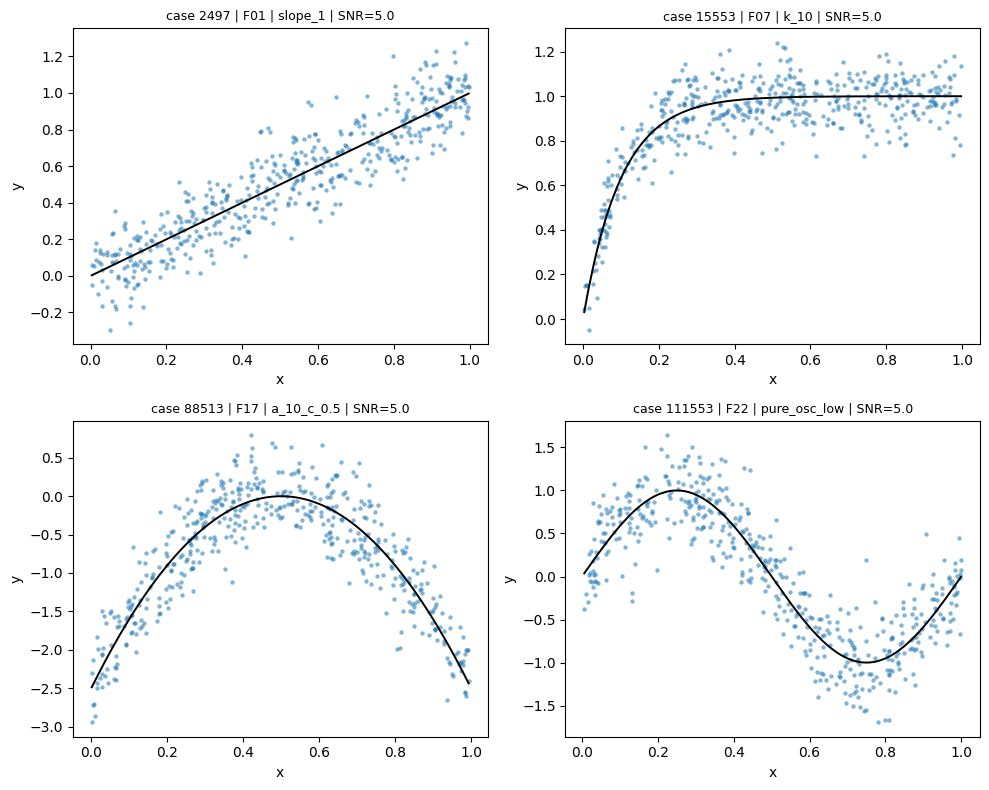

In [22]:
def plot_case(case_id: int, replicate: int = 0, n: int | None = None, ax: Any | None = None) -> Any:
    df = generate_scatter(case_id, replicate=replicate, n=n)
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))
    ax.scatter(df["x"], df["y"], s=10, alpha=0.55, linewidths=0)
    order = np.argsort(df["x"].to_numpy())
    ax.plot(df["x"].to_numpy()[order], df["y_signal"].to_numpy()[order], color="black", lw=1.4)
    title = f"case {case_id} | {df.family_id.iloc[0]} | {df.variant_name.iloc[0]} | SNR={df.snr.iloc[0]}"
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    return ax


plot_ids = [
    int(cases_df.query("family_id == 'F01' and variant_name == 'slope_1' and spread_pattern == 'constant' and x_distribution == 'even' and snr == 5").iloc[0].case_id),
    int(cases_df.query("family_id == 'F07' and variant_name == 'k_10' and spread_pattern == 'constant' and x_distribution == 'even' and snr == 5").iloc[0].case_id),
    int(cases_df.query("family_id == 'F17' and variant_name == 'a_10_c_0.5' and spread_pattern == 'constant' and x_distribution == 'even' and snr == 5").iloc[0].case_id),
    int(cases_df.query("family_id == 'F22' and variant_name == 'pure_osc_low' and spread_pattern == 'constant' and x_distribution == 'even' and snr == 5").iloc[0].case_id),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, case_id in zip(axes.flat, plot_ids):
    plot_case(case_id, replicate=0, ax=ax)
plt.tight_layout()
plt.show()

## Export: cases.csv + scatter_points.npz

Two-file storage for all downstream uses:

| File | Content | Rows / Shape |
|------|---------|-------------|
| `cases.csv` | Labels + parameters per case | 114,432 rows |
| `scatter_points.npz` | x, y, y_signal coordinate arrays | (114432, 500) each |

- **Metrics ML**: load npz → compute metrics per case → join with cases.csv labels
- **CNN**: load npz → render as images
- **Point-set ML**: load npz coordinates directly as input


In [29]:
OUTPUT_DIR = Path("generated_scatterplot_data")


def export_all(output_dir: Path = OUTPUT_DIR) -> None:
    output_dir.mkdir(parents=True, exist_ok=True)
    n_cases = len(cases_df)

    # ── 1. cases.csv ──
    cases_path = output_dir / "cases.csv"
    cases_df.to_csv(cases_path, index=False)
    print(f"✓ Saved {cases_path}  ({n_cases} rows)")

    # ── 2. scatter_points.npz ──
    x_all = np.empty((n_cases, N_PER_CASE), dtype=np.float32)
    y_all = np.empty((n_cases, N_PER_CASE), dtype=np.float32)
    y_signal_all = np.empty((n_cases, N_PER_CASE), dtype=np.float32)

    t0 = time.time()
    for idx, (_, row) in enumerate(cases_df.iterrows()):
        cid = int(row["case_id"])
        df_pts = generate_scatter(cid, replicate=0)
        x_all[idx] = df_pts["x"].values.astype(np.float32)
        y_all[idx] = df_pts["y"].values.astype(np.float32)
        y_signal_all[idx] = df_pts["y_signal"].values.astype(np.float32)

        if (idx + 1) % 10000 == 0:
            elapsed = time.time() - t0
            rate = (idx + 1) / elapsed
            eta = (n_cases - idx - 1) / rate
            print(f"  {idx+1:>7d}/{n_cases}  ({rate:.0f} cases/s, ETA {eta:.0f}s)")

    npz_path = output_dir / "scatter_points.npz"
    np.savez_compressed(npz_path, x=x_all, y=y_all, y_signal=y_signal_all)
    size_mb = npz_path.stat().st_size / 1e6
    elapsed = time.time() - t0
    print(f"✓ Saved {npz_path}  shape=({n_cases}, {N_PER_CASE})  {size_mb:.1f} MB  ({elapsed:.0f}s)")


export_all()


✓ Saved generated_scatterplot_data/cases.csv  (114176 rows)
    10000/114176  (1274 cases/s, ETA 82s)
    20000/114176  (1372 cases/s, ETA 69s)
    30000/114176  (1394 cases/s, ETA 60s)
    40000/114176  (1378 cases/s, ETA 54s)
    50000/114176  (1402 cases/s, ETA 46s)
    60000/114176  (1420 cases/s, ETA 38s)
    70000/114176  (1427 cases/s, ETA 31s)
    80000/114176  (1423 cases/s, ETA 24s)
    90000/114176  (1422 cases/s, ETA 17s)
   100000/114176  (1417 cases/s, ETA 10s)
   110000/114176  (1414 cases/s, ETA 3s)
✓ Saved generated_scatterplot_data/scatter_points.npz  shape=(114176, 500)  540.2 MB  (103s)


## Reproducibility Check

The same `case_id` and `replicate` should produce identical point-level data.


In [24]:
a = generate_scatter(example_case_id, replicate=7)
b = generate_scatter(example_case_id, replicate=7)
c = generate_scatter(example_case_id, replicate=8)

assert a.equals(b)
assert not a[["x", "y"]].equals(c[["x", "y"]])

print("Reproducibility check passed.")
print(f"Notebook implements {len(shape_configs)} shape configs and {len(cases_df)} cases from the explicit parameter lists.")


Reproducibility check passed.
Notebook implements 301 shape configs and 114176 cases from the explicit parameter lists.


## Representative Scatterplot Overview

This plots 23 representative scatterplots in one figure: F01–F22 plus Null. Each subtitle shows the function-family name and its equation or representation. Positive/negative direction pairs are shown side by side.

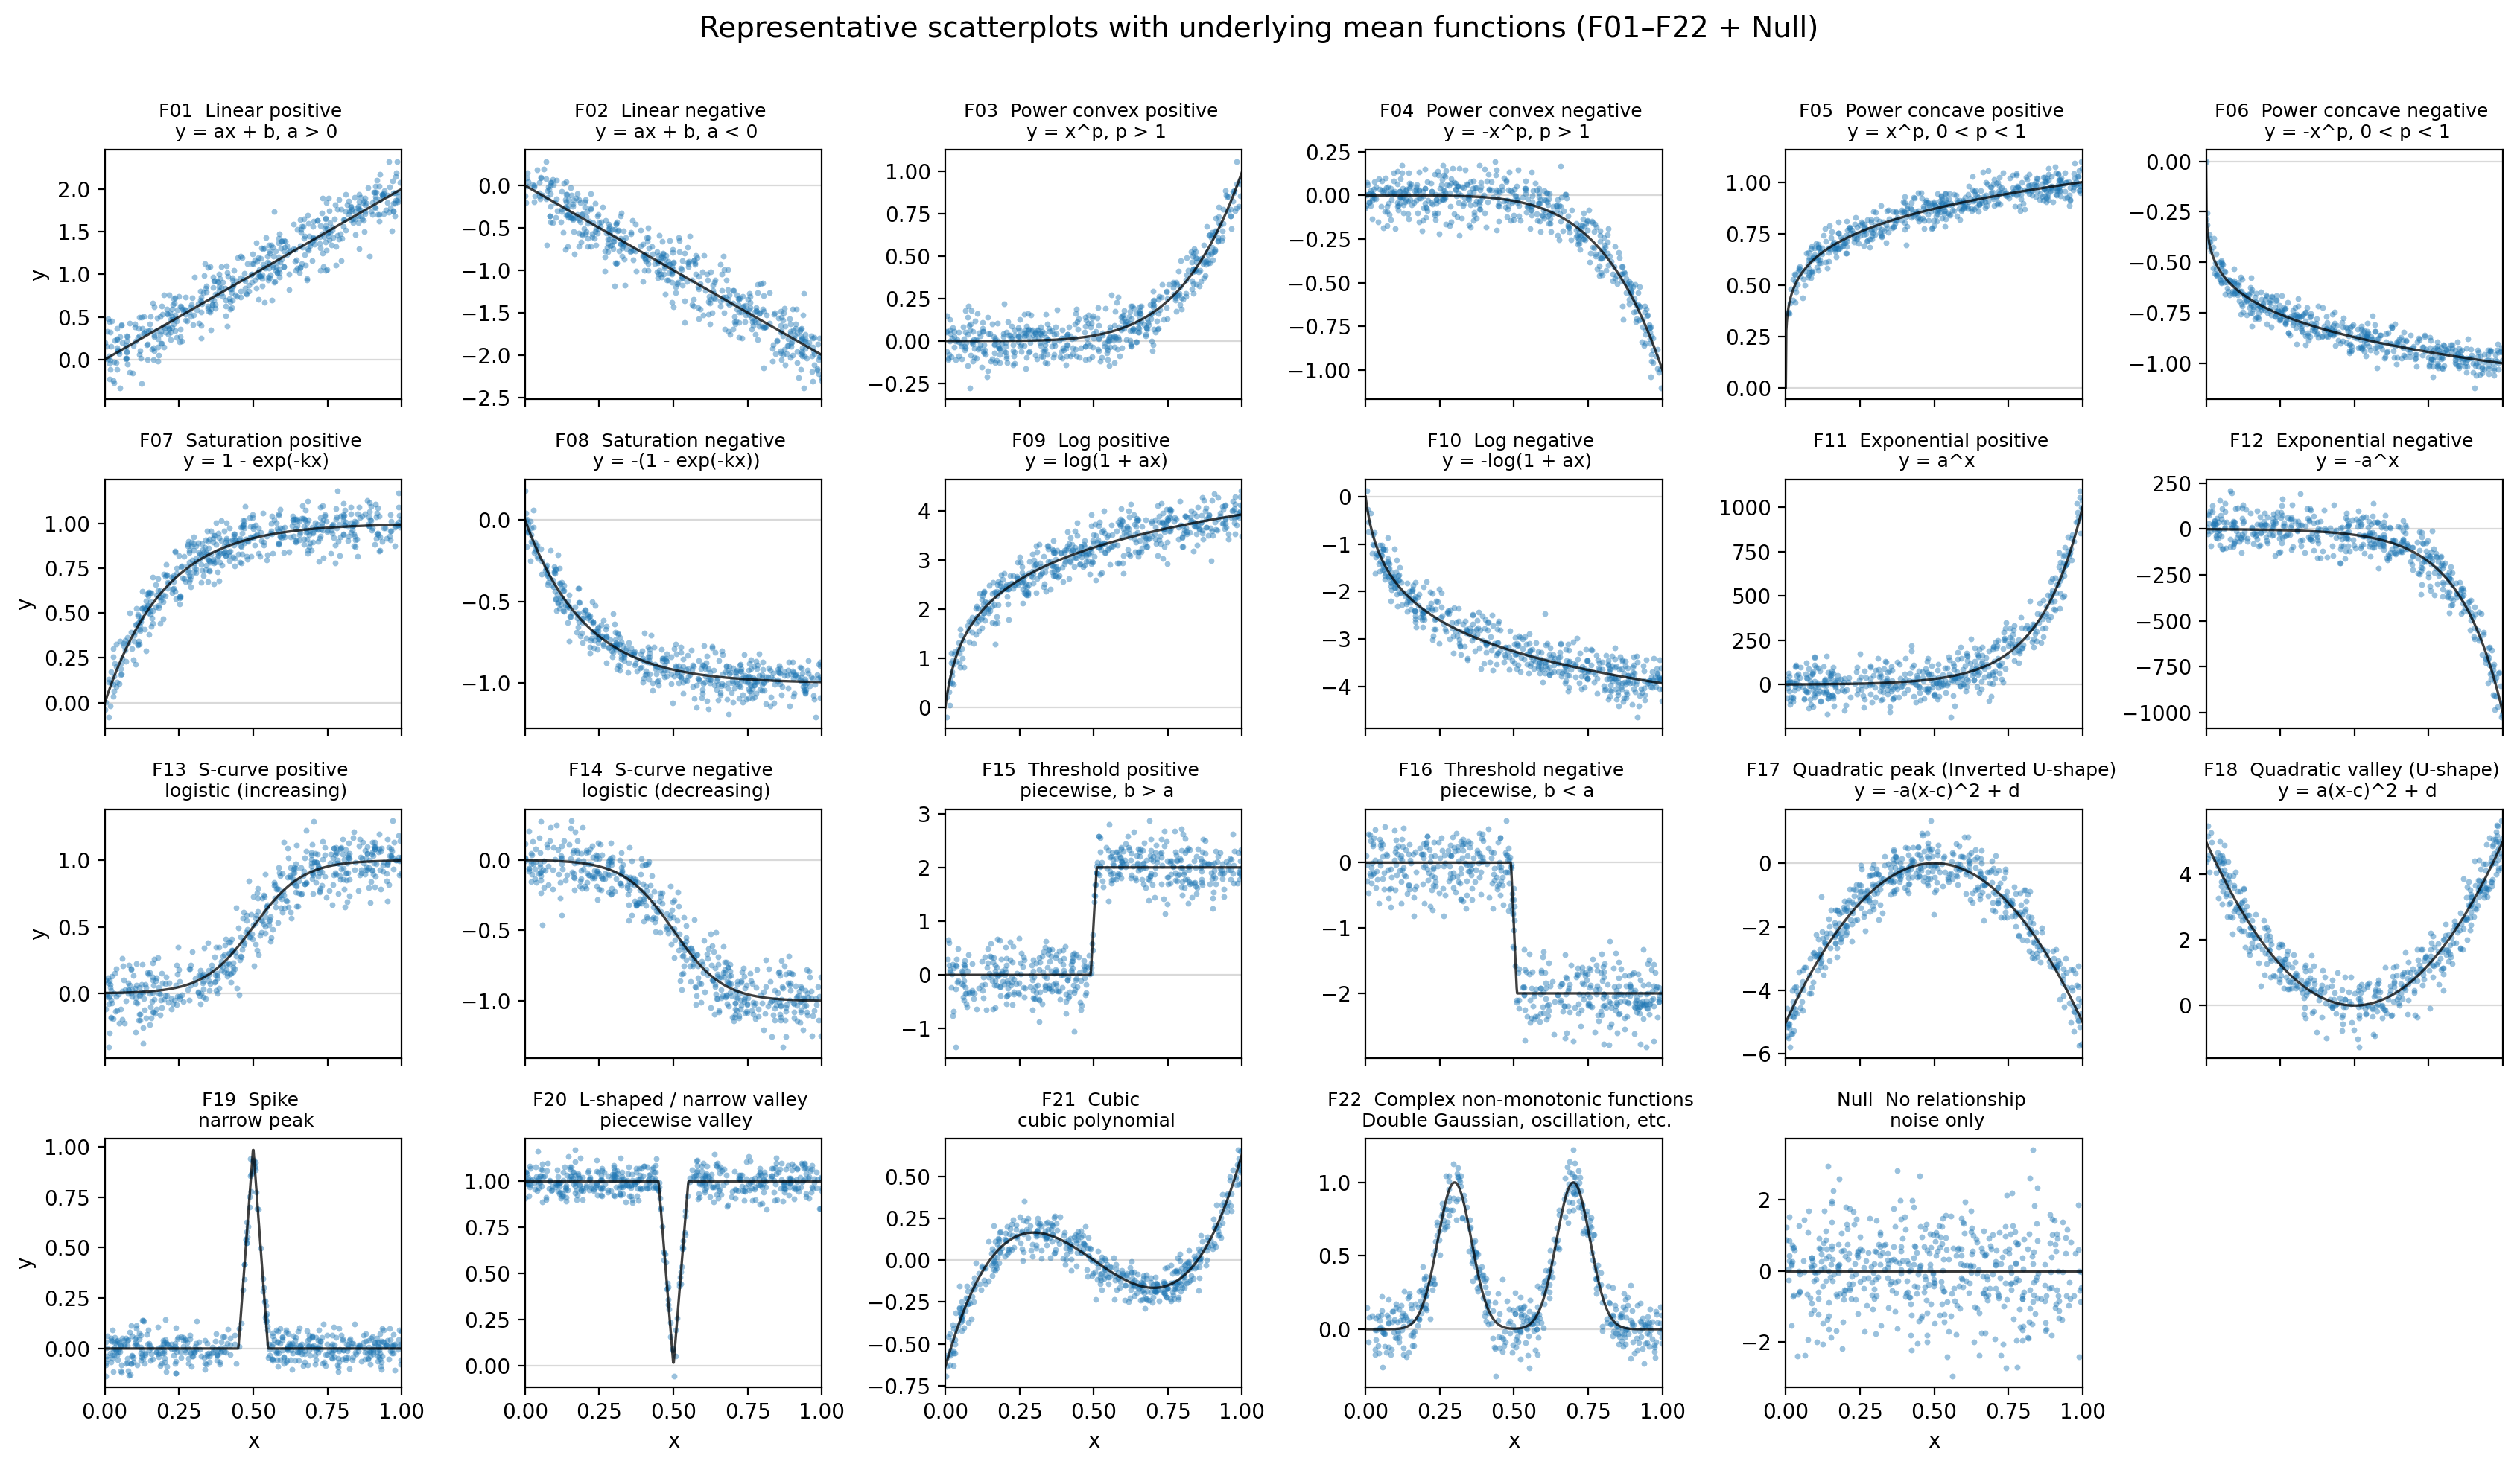

In [25]:
def _first_config(family_id: str, variant_name: str | None = None) -> ShapeConfig:
    for cfg in shape_configs:
        if cfg.family_id == family_id and (variant_name is None or cfg.variant_name == variant_name):
            return cfg
    raise LookupError(f"No config found for {family_id}, variant={variant_name}")


def _family_subtitle(cfg: ShapeConfig) -> str:
    labels = cfg.labels
    return f"{labels['family_name']} \n {labels['equation_presentation']}"


representative_scatter_specs = [
    _first_config("F01", "slope_2"),
    _first_config("F02", "slope_-2"),
    _first_config("F03", "p_5"),
    _first_config("F04", "p_5"),
    _first_config("F05", "p_0.2"),
    _first_config("F06", "p_0.2"),
    _first_config("F07", "k_5"),
    _first_config("F08", "k_5"),
    _first_config("F09", "a_50"),
    _first_config("F10", "a_50"),
    _first_config("F11", "base_10_range_3"),
    _first_config("F12", "base_10_range_3"),
    _first_config("F13", "k_12_c_0.5"),
    _first_config("F14", "k_12_c_0.5"),
    _first_config("F15", "gap_2_delta_0.01_c_0.5"),
    _first_config("F16", "gap_2_delta_0.01_c_0.5"),
    _first_config("F17", "a_20_c_0.5"),
    _first_config("F18", "a_20_c_0.5"),
    _first_config("F19", "width_0.05_c_0.5"),
    _first_config("F20", "width_0.05_c_0.5"),
    _first_config("F21", "cubic_m_center_wide"),
    _first_config("F22", "double_gaussian_equal"),
    _first_config("Null", "independent_normal"),
]

scatter_rng = np.random.default_rng(20260617)
x_grid = np.linspace(0.0, 1.0, 600)
n_panels = len(representative_scatter_specs)
ncols = 6
nrows = math.ceil(n_panels / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(17, nrows * 2.5), sharex=True, dpi=200)

for ax, cfg in zip(axes.flat, representative_scatter_specs):
    x_points = scatter_rng.uniform(0.0, 1.0, size=N_PER_CASE)
    y_signal_points = evaluate_signal(x_points, cfg)
    if cfg.family_id == "Null":
        y_points = scatter_rng.normal(0.0, 1.0, size=N_PER_CASE)
    else:
        sigma0 = sigma0_for_snr(cfg, 10)
        y_points = y_signal_points + scatter_rng.normal(0.0, sigma0, size=N_PER_CASE)
    y_grid = evaluate_signal(x_grid, cfg)
    ax.scatter(x_points, y_points, s=8, alpha=0.45, linewidths=0)
    ax.plot(x_grid, y_grid, color="black", lw=1.2, alpha=0.75)
    ax.axhline(0, color="0.85", lw=0.8, zorder=0)
    ax.set_title(f"{cfg.family_id}  {_family_subtitle(cfg)}", fontsize=9)
    ax.set_xlim(0, 1)

for ax in axes.flat[n_panels:]:
    ax.axis("off")

for ax in axes[-1, :]:
    ax.set_xlabel("x")
for ax in axes[:, 0]:
    ax.set_ylabel("y")

fig.suptitle("Representative scatterplots with underlying mean functions (F01–F22 + Null)", fontsize=14)
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()


## Scatterplots for All Parameter Variants by Family

Each function family gets one figure. Inside that figure, each panel shows one parameter variant for the same family. Scatter points are generated at `SNR=5` with `n=500`, and the black line shows the noiseless mean function. Negative direction families (F04, F06, F08, F10, F12, F14, F16) share the same parameter variants as their positive counterparts but with negated output.

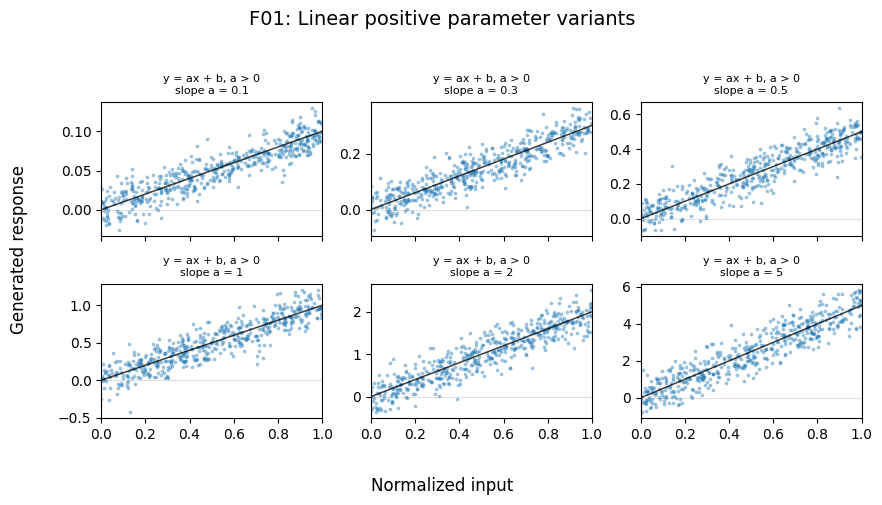

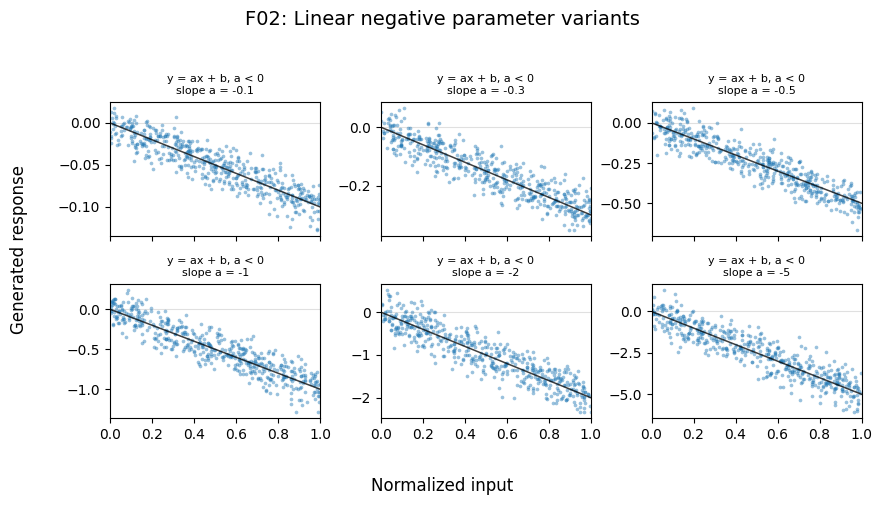

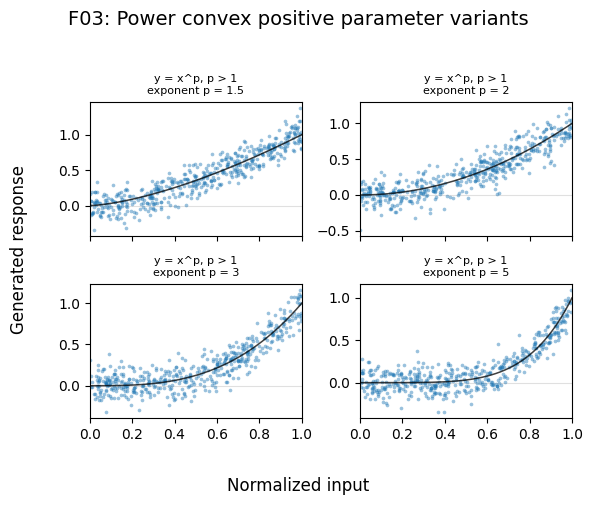

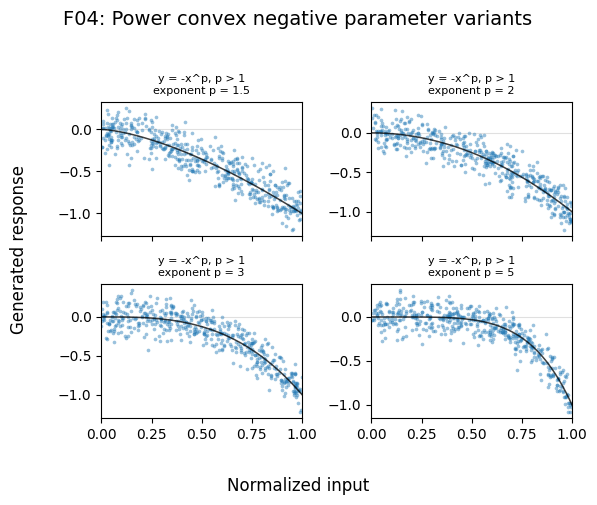

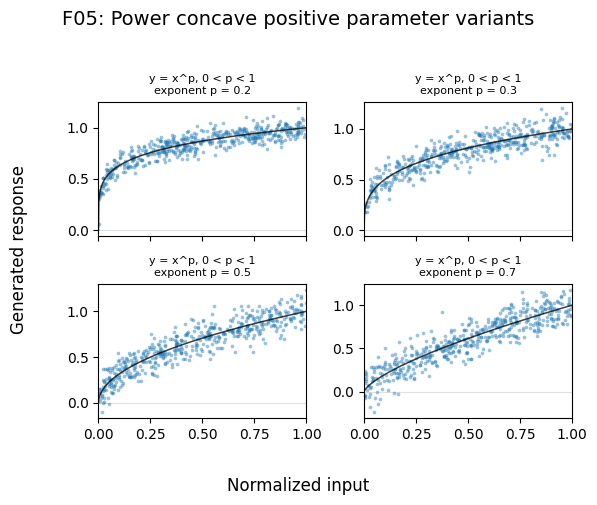

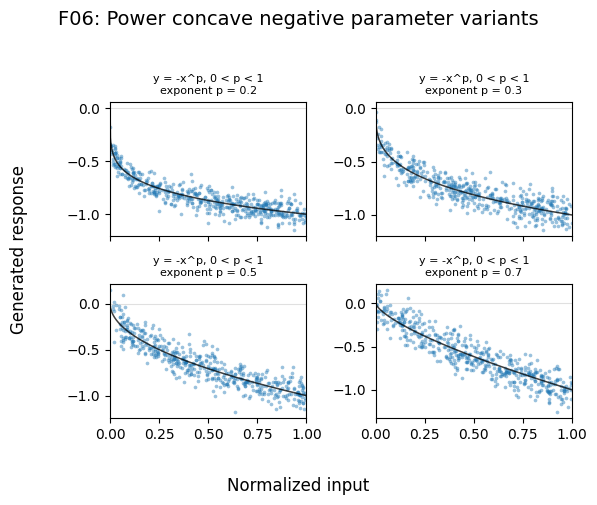

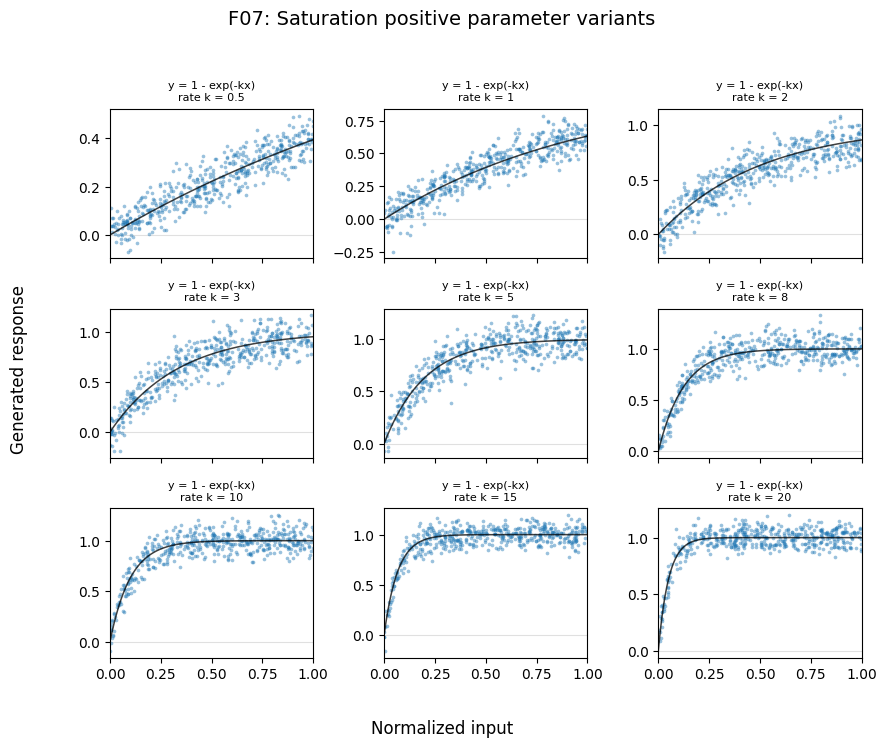

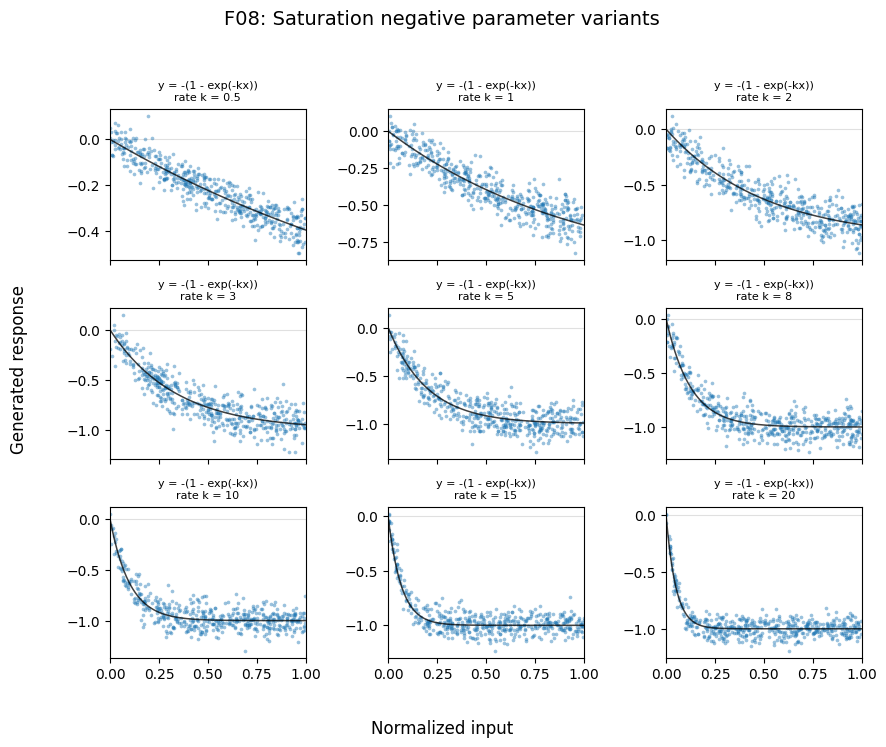

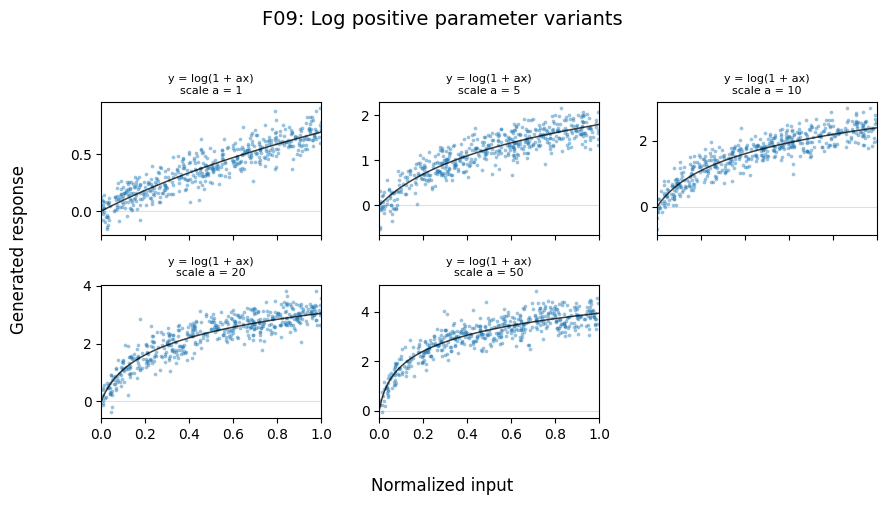

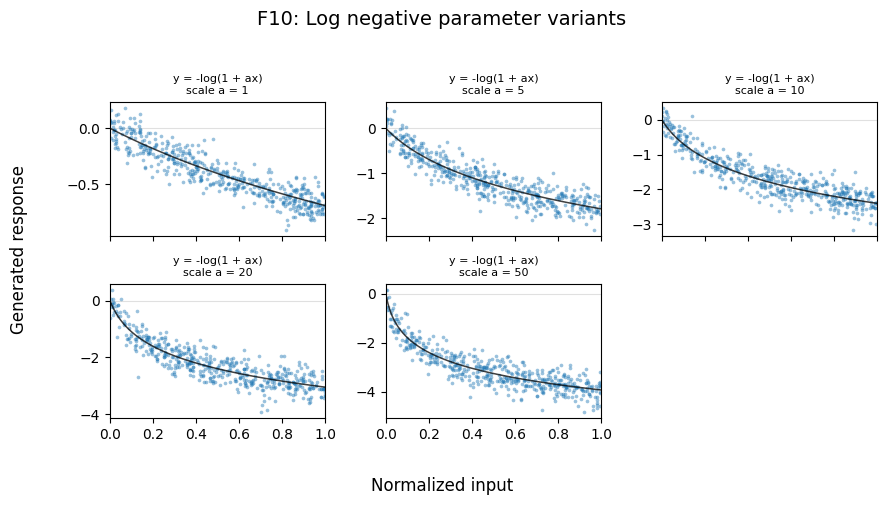

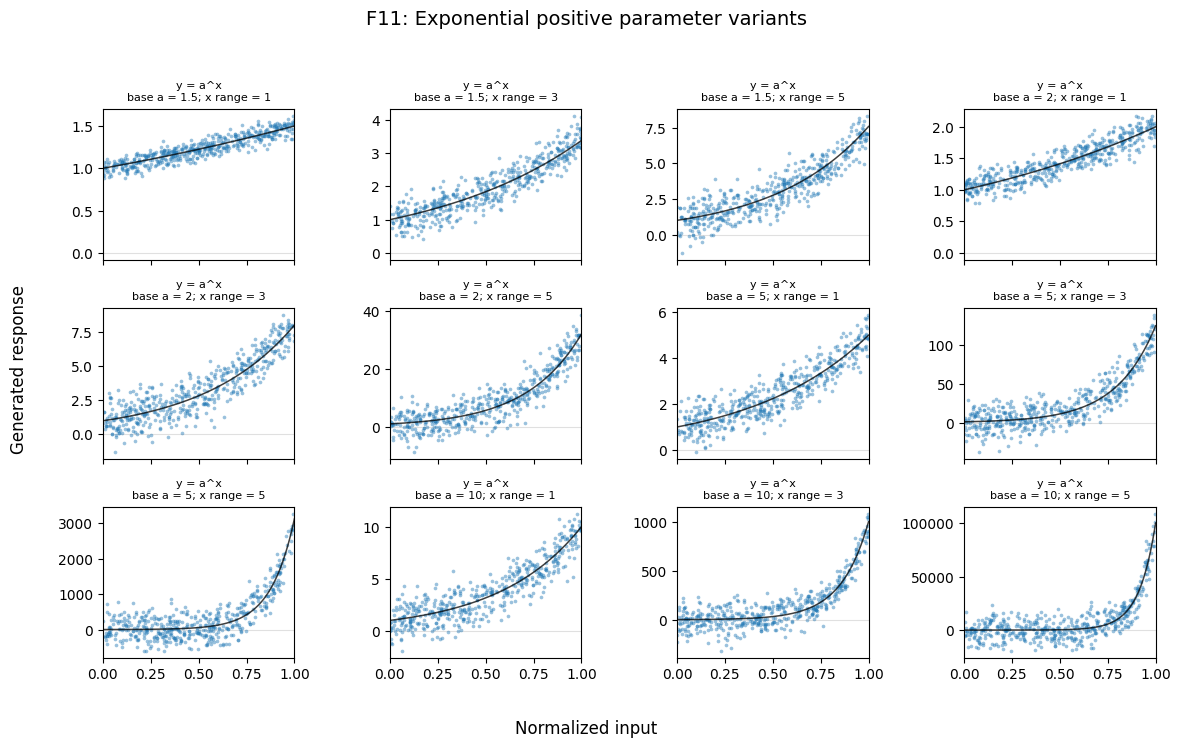

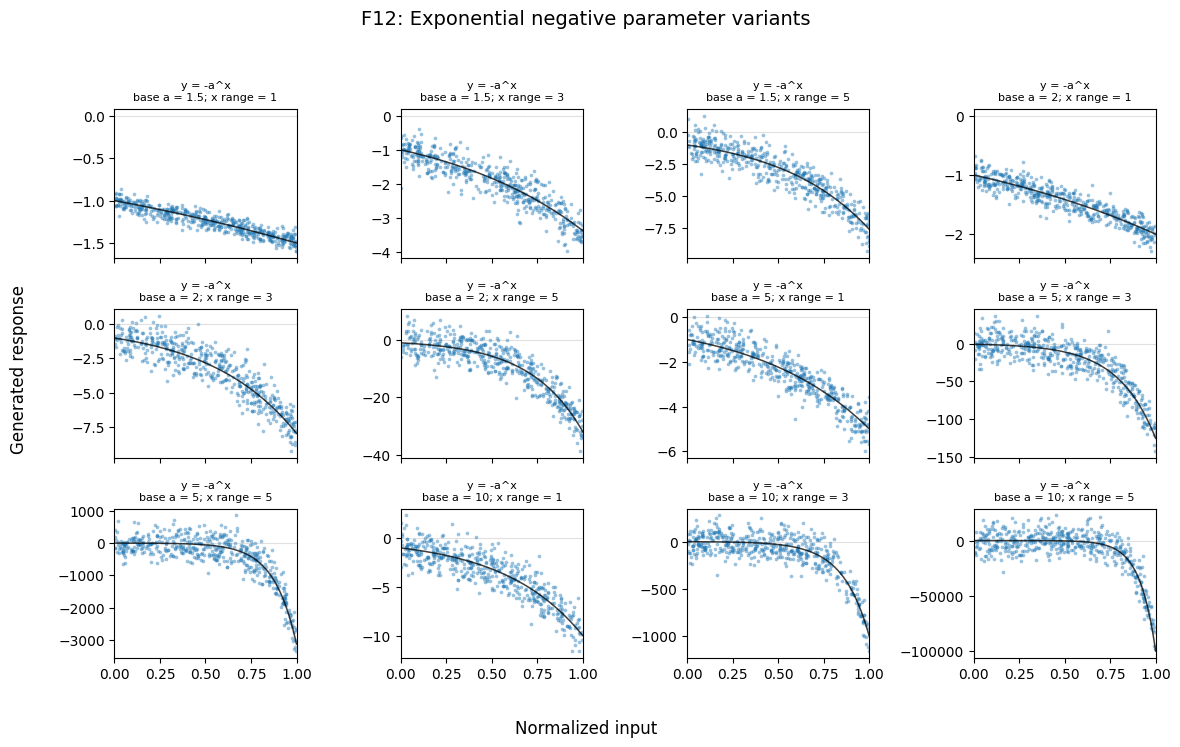

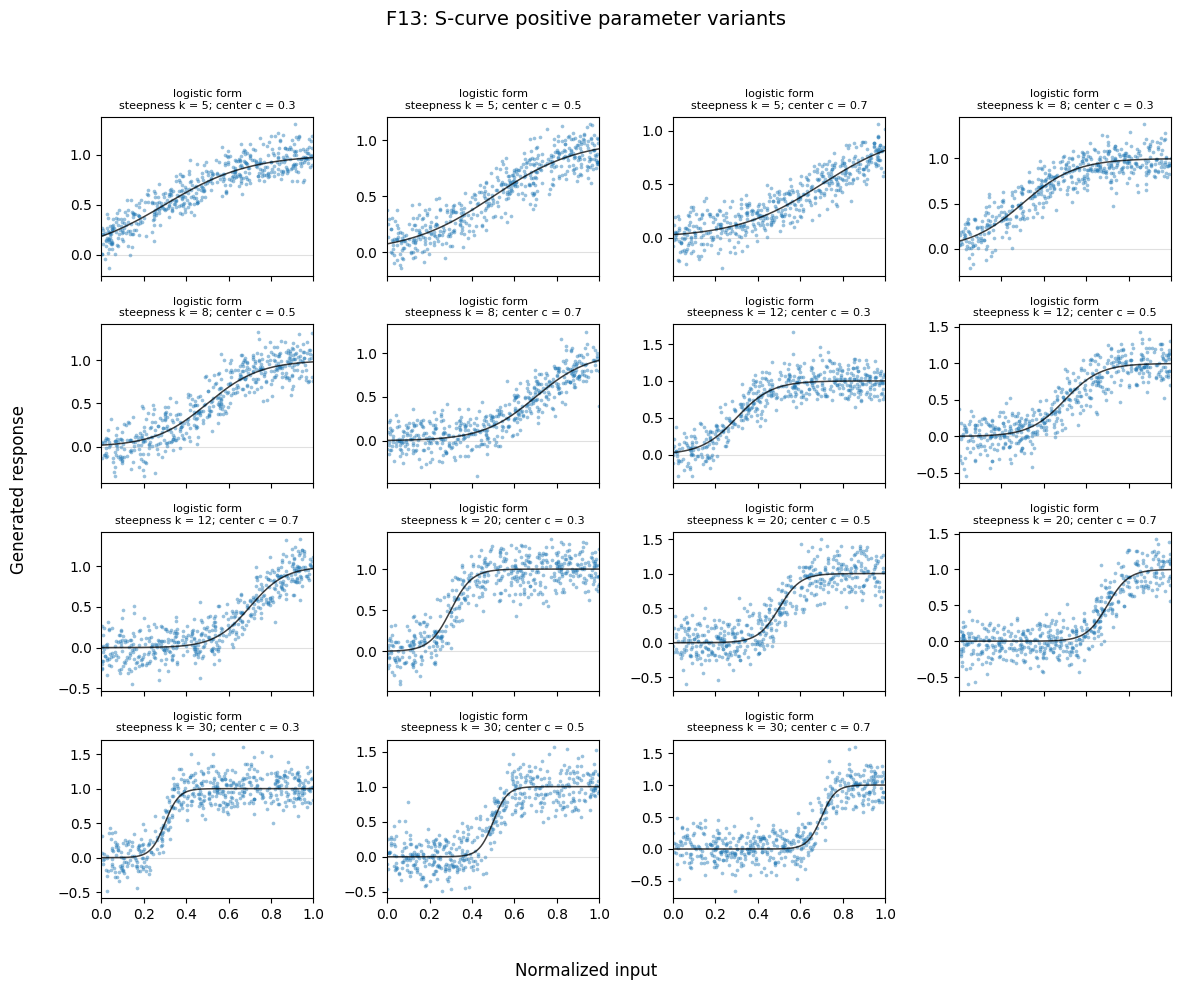

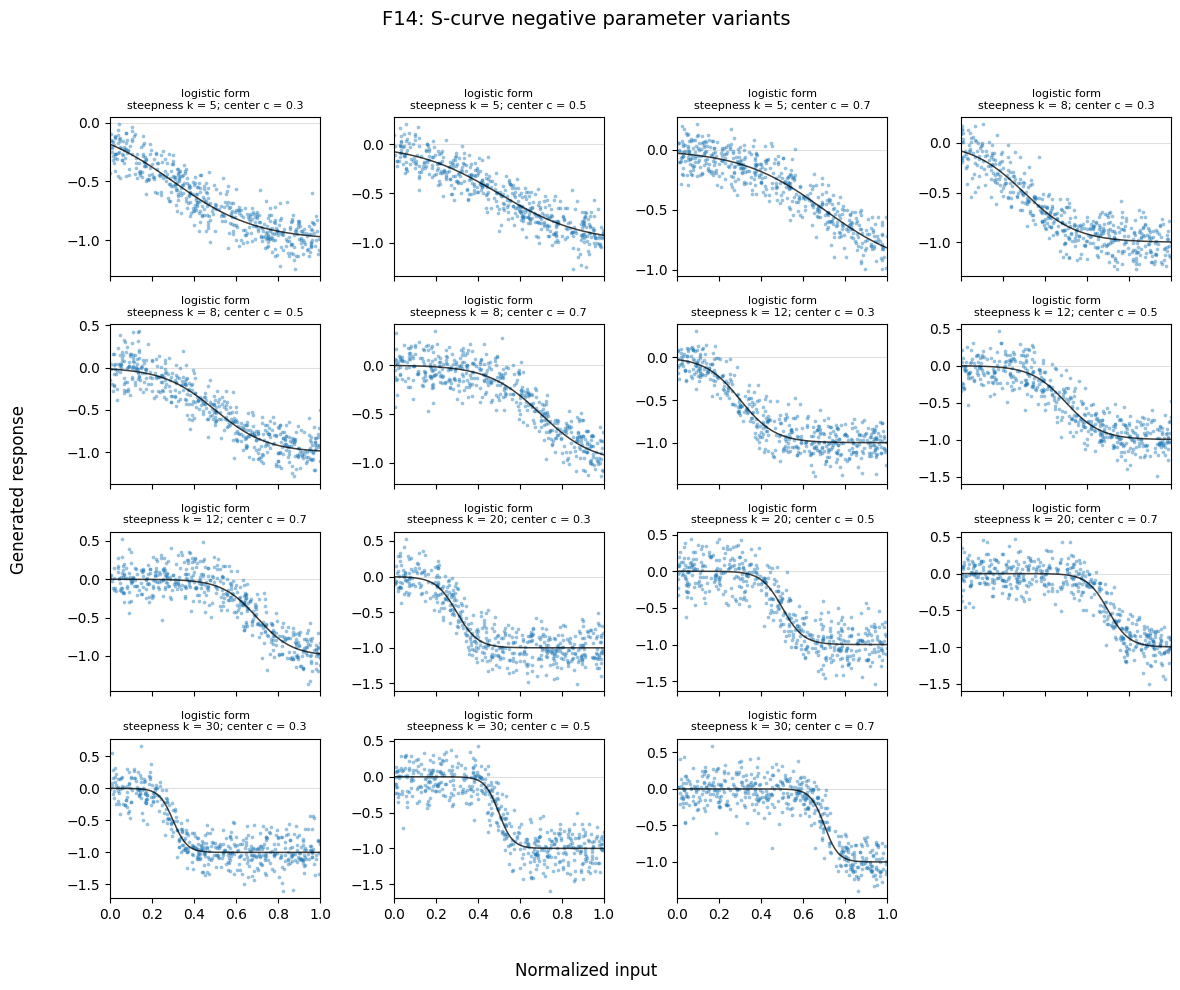

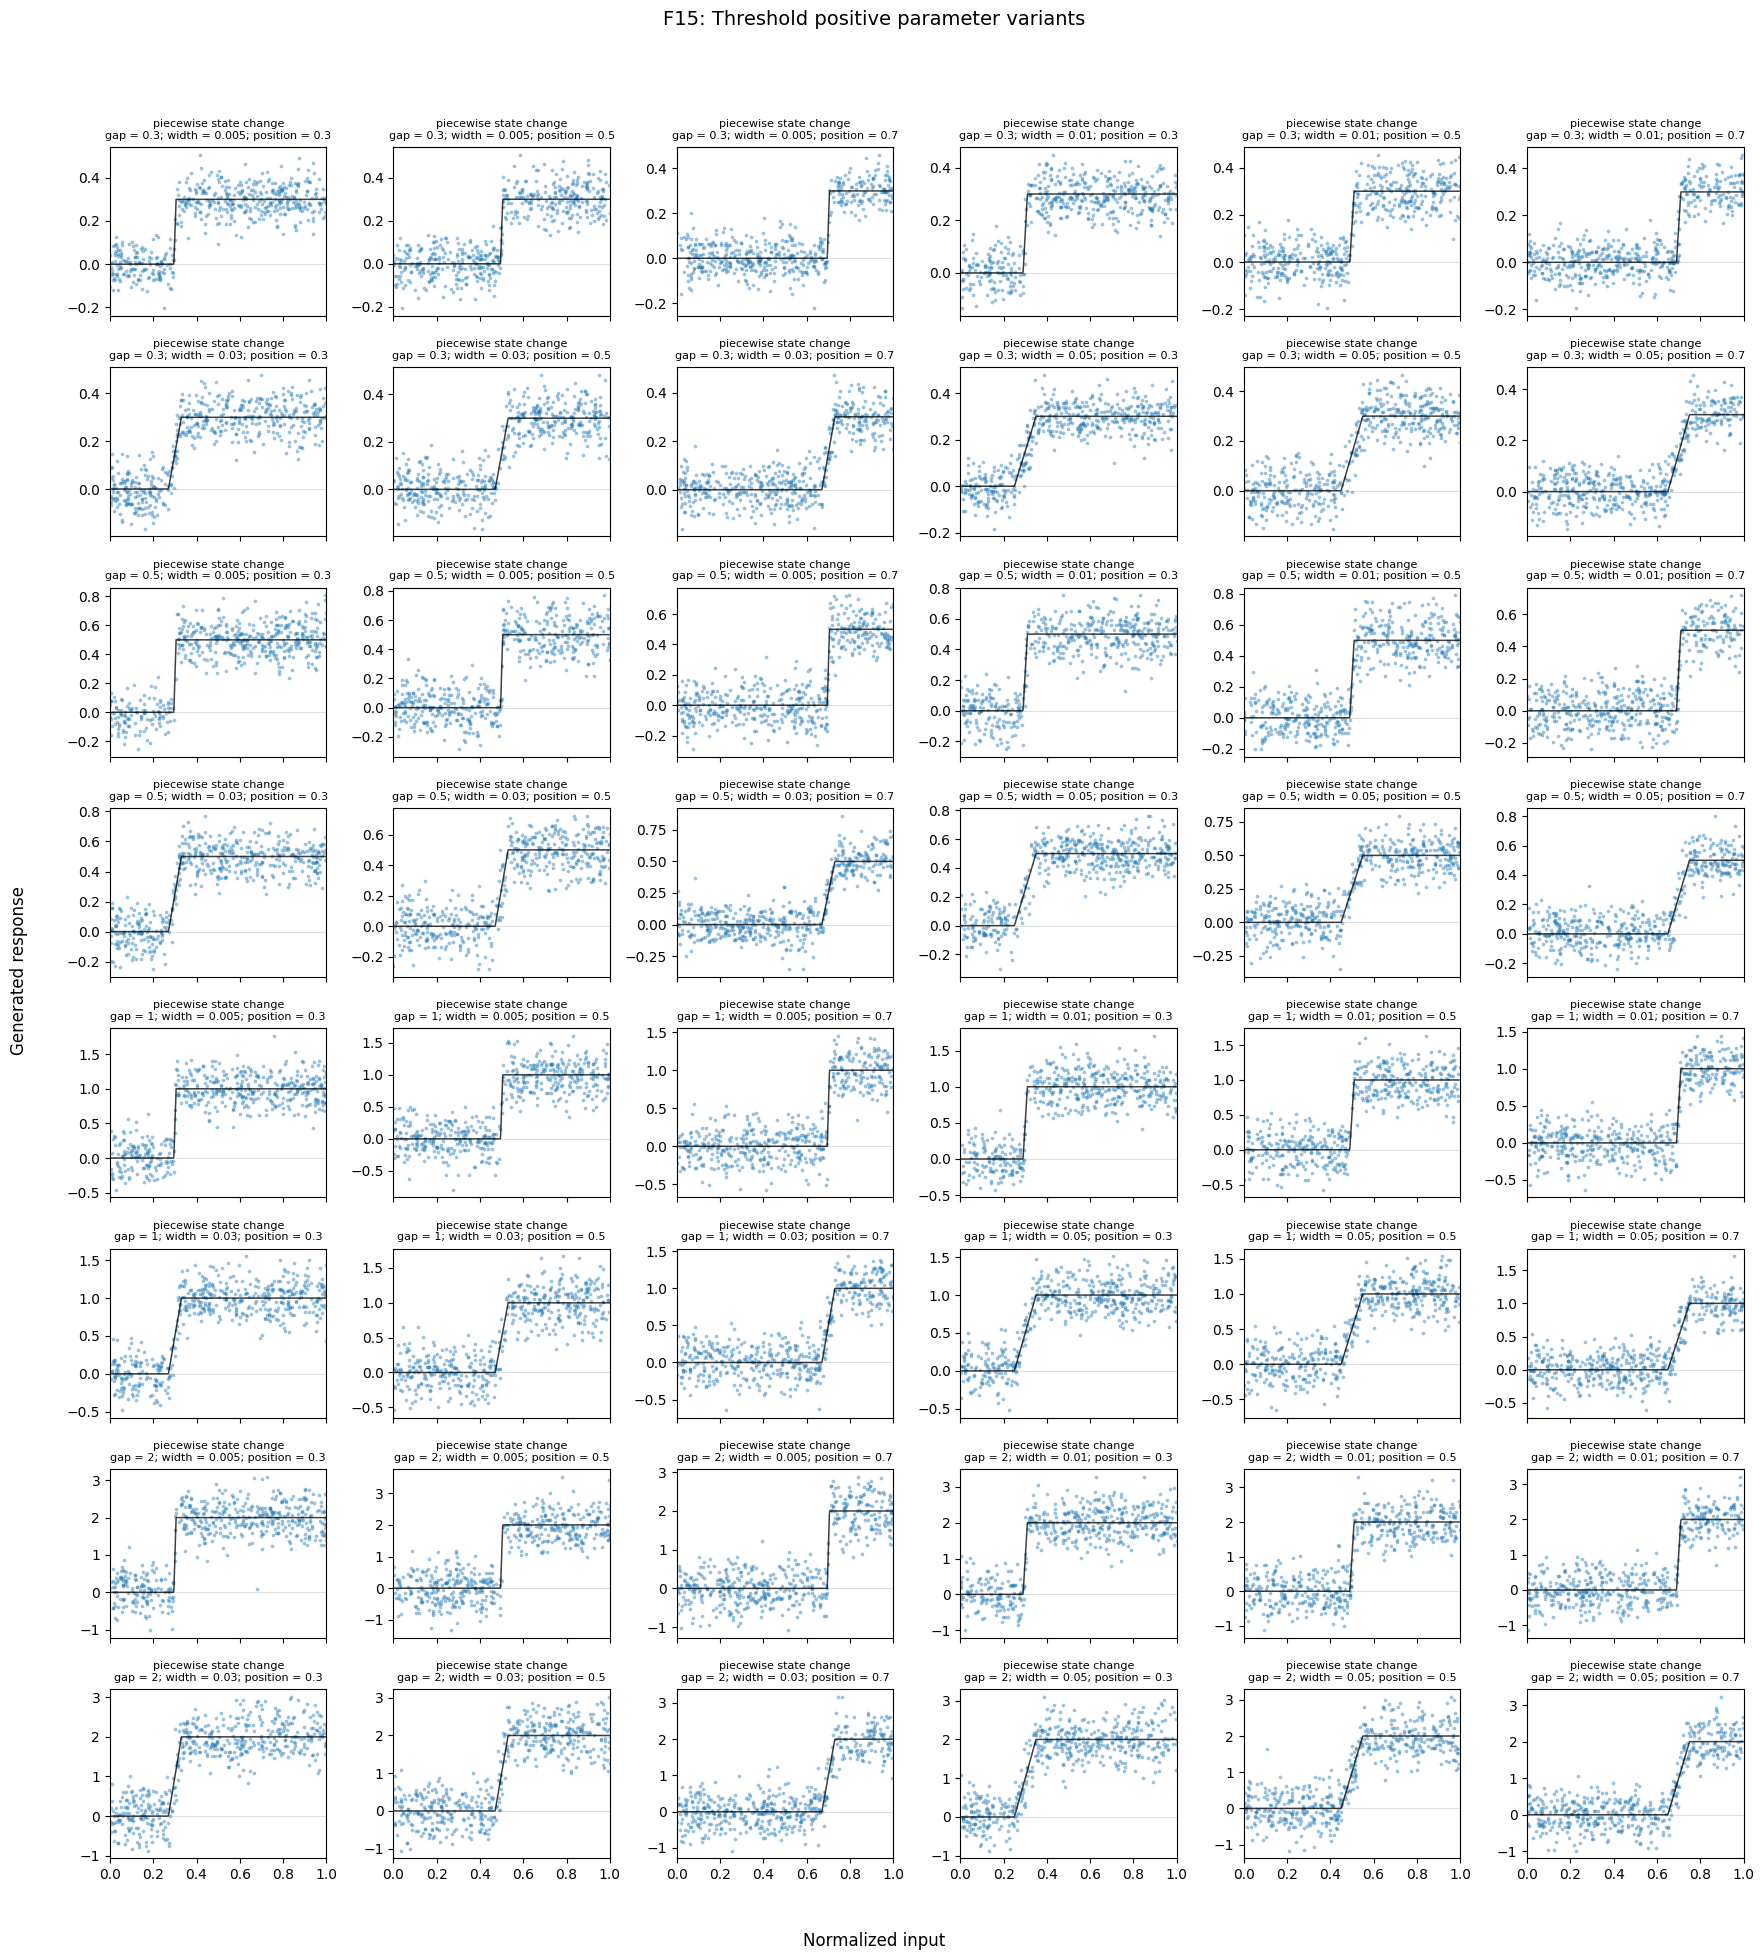

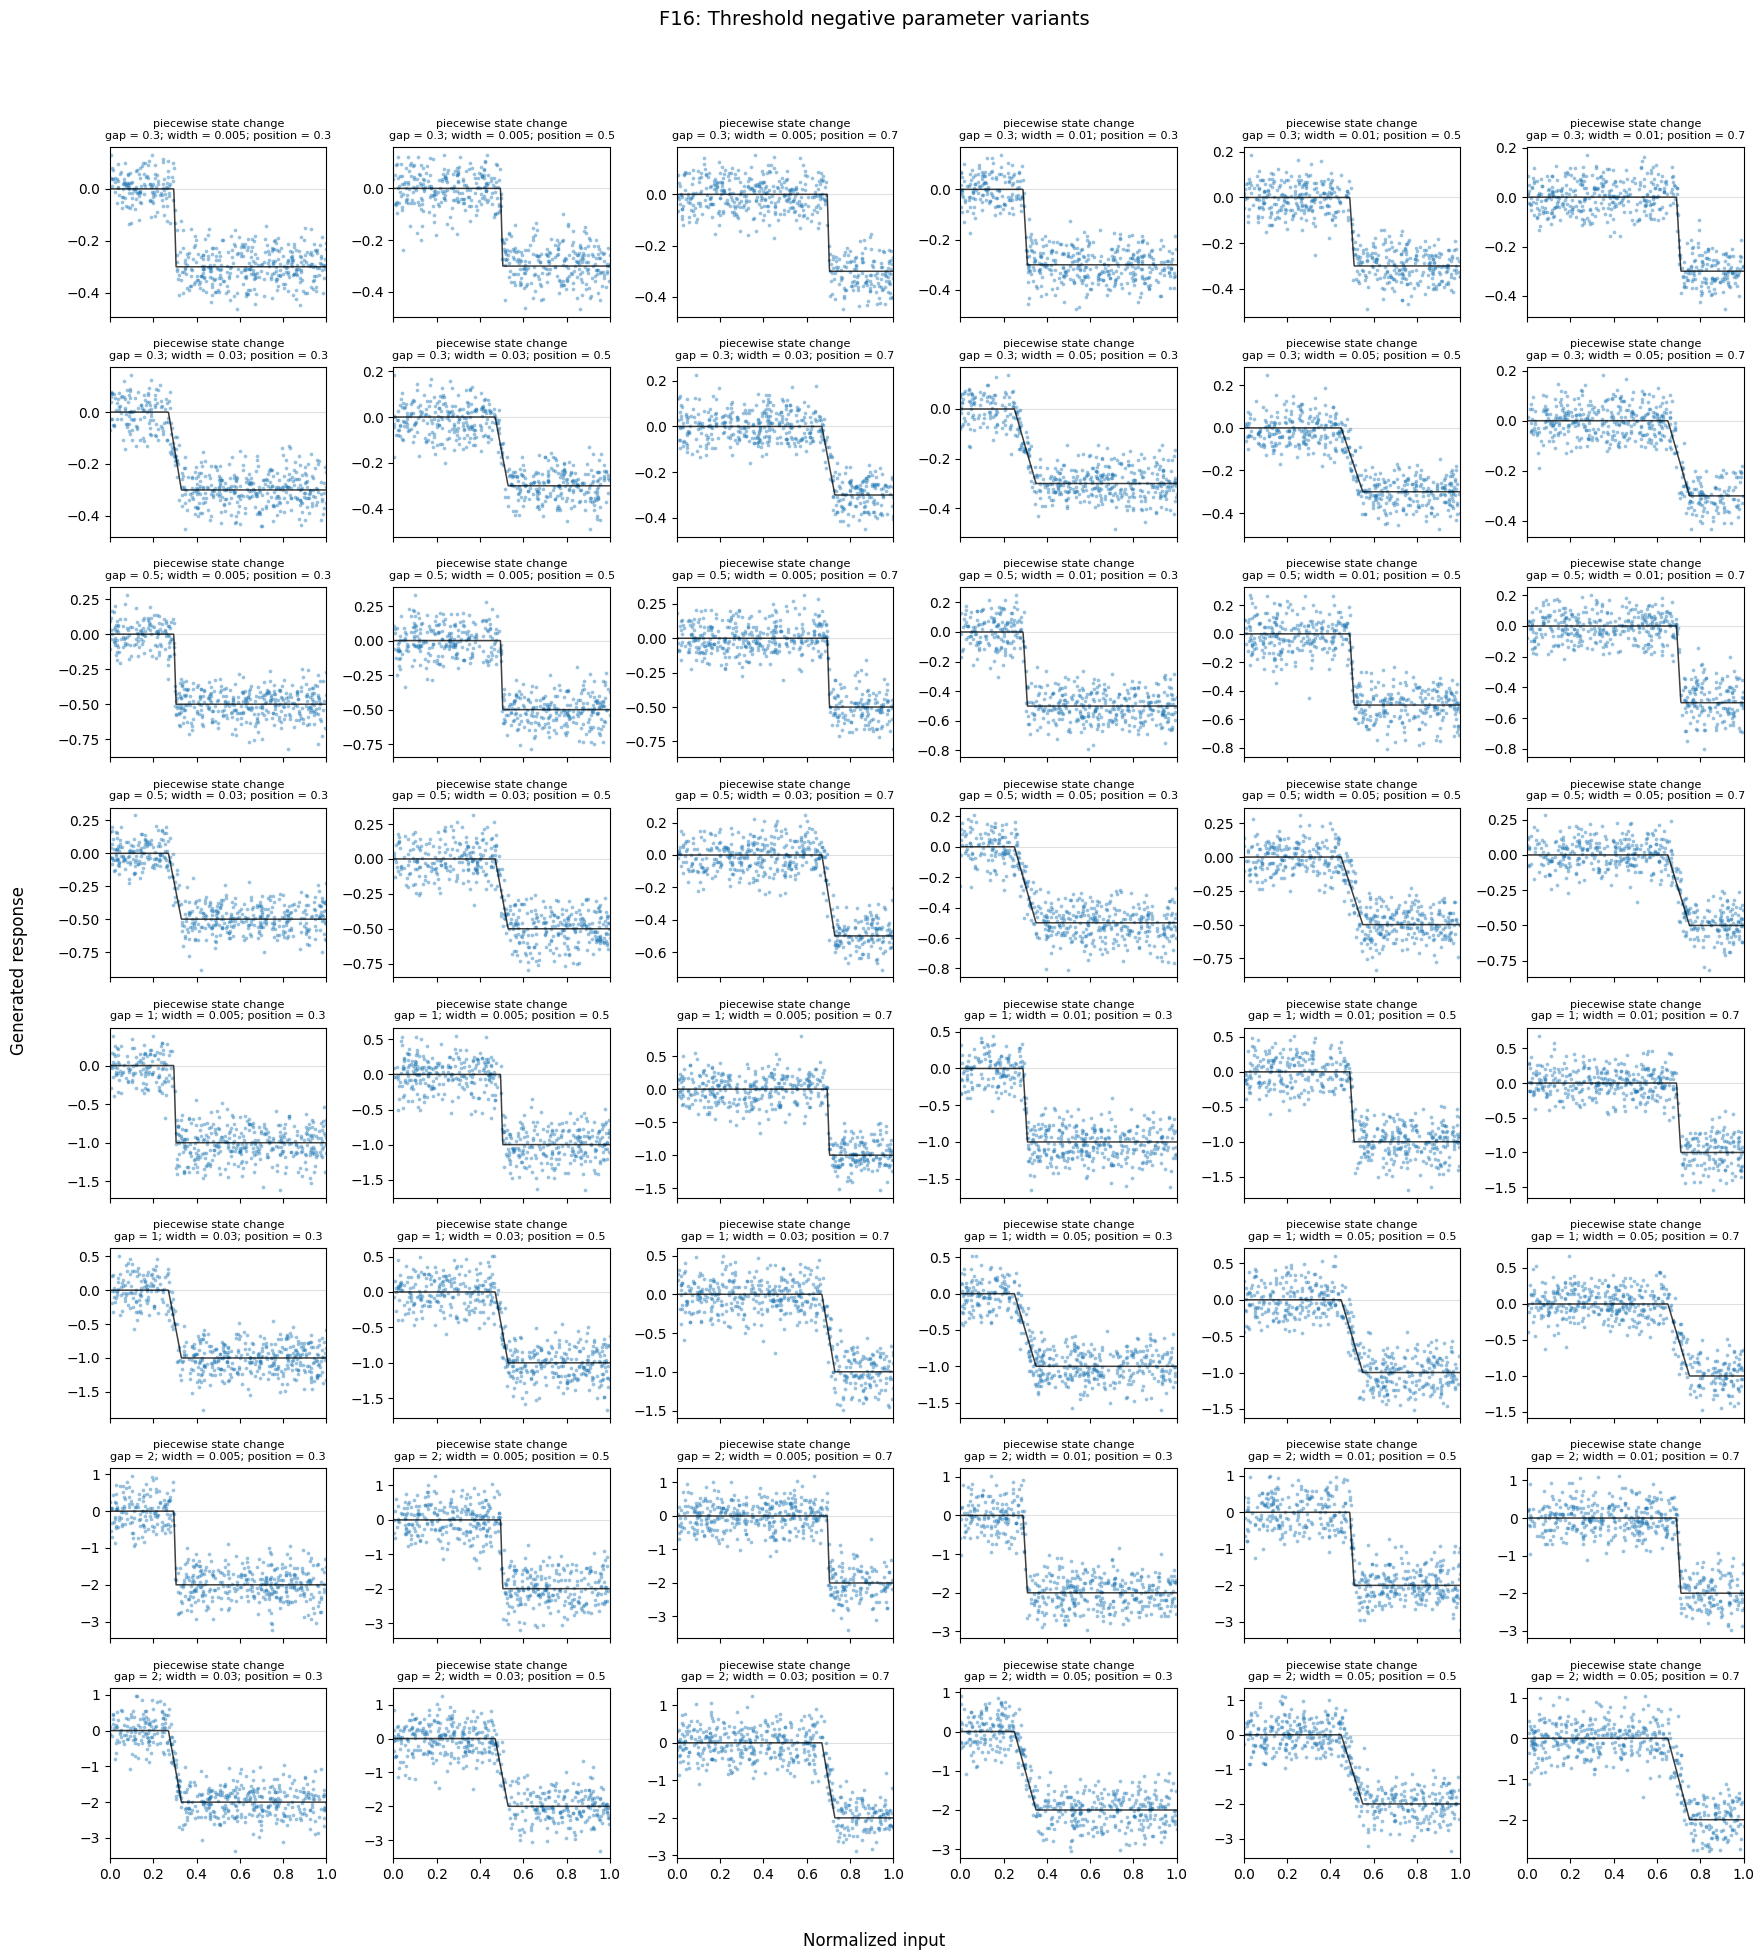

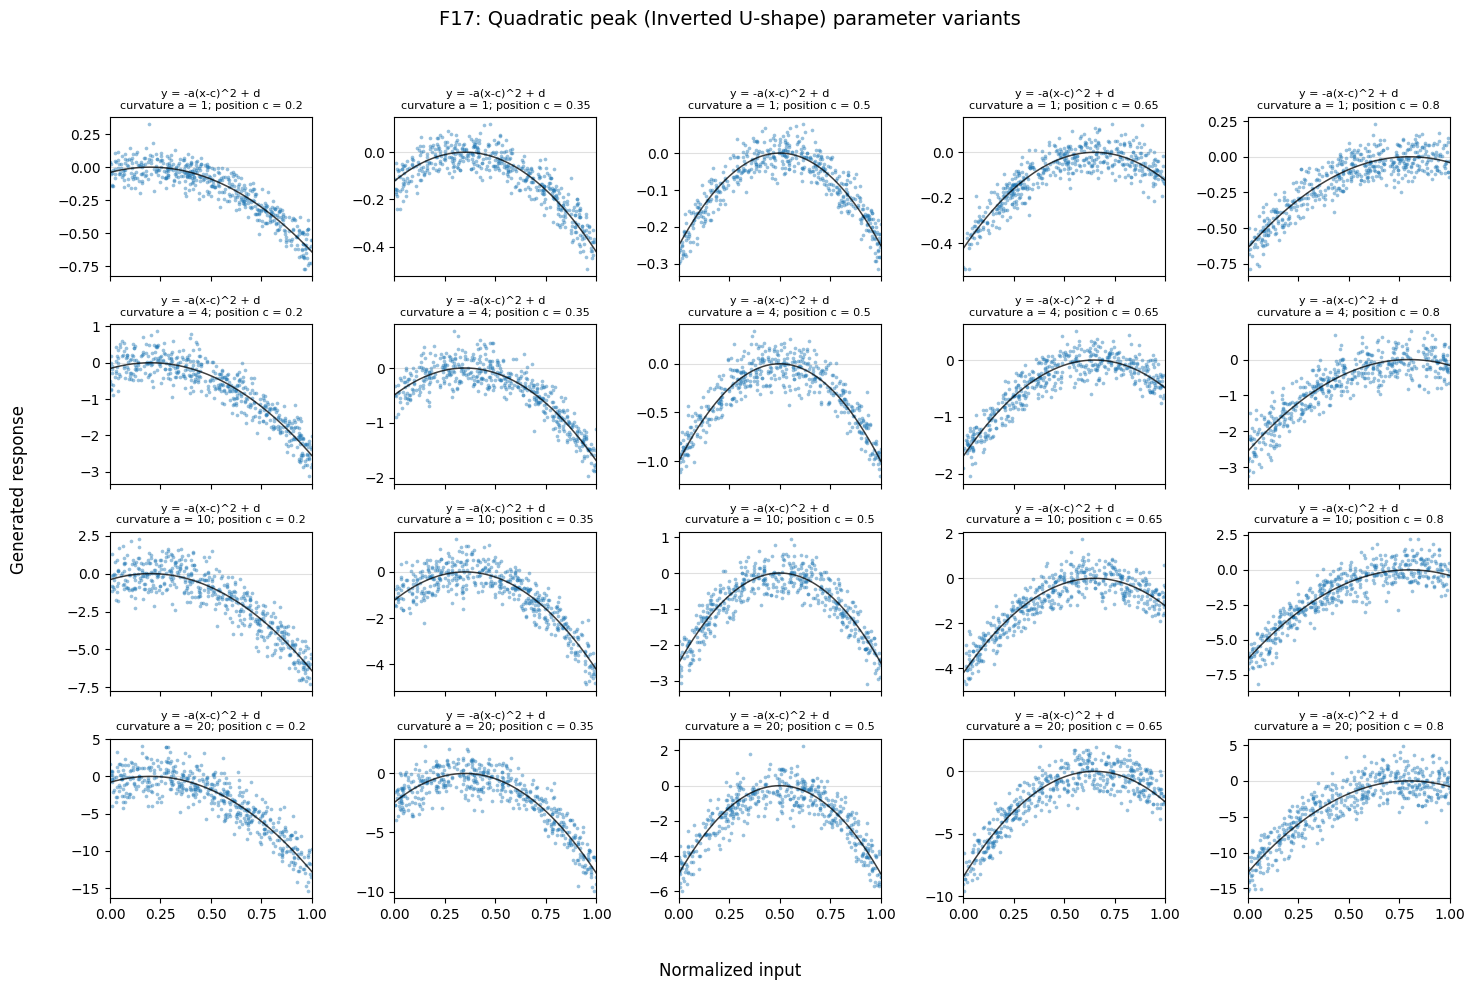

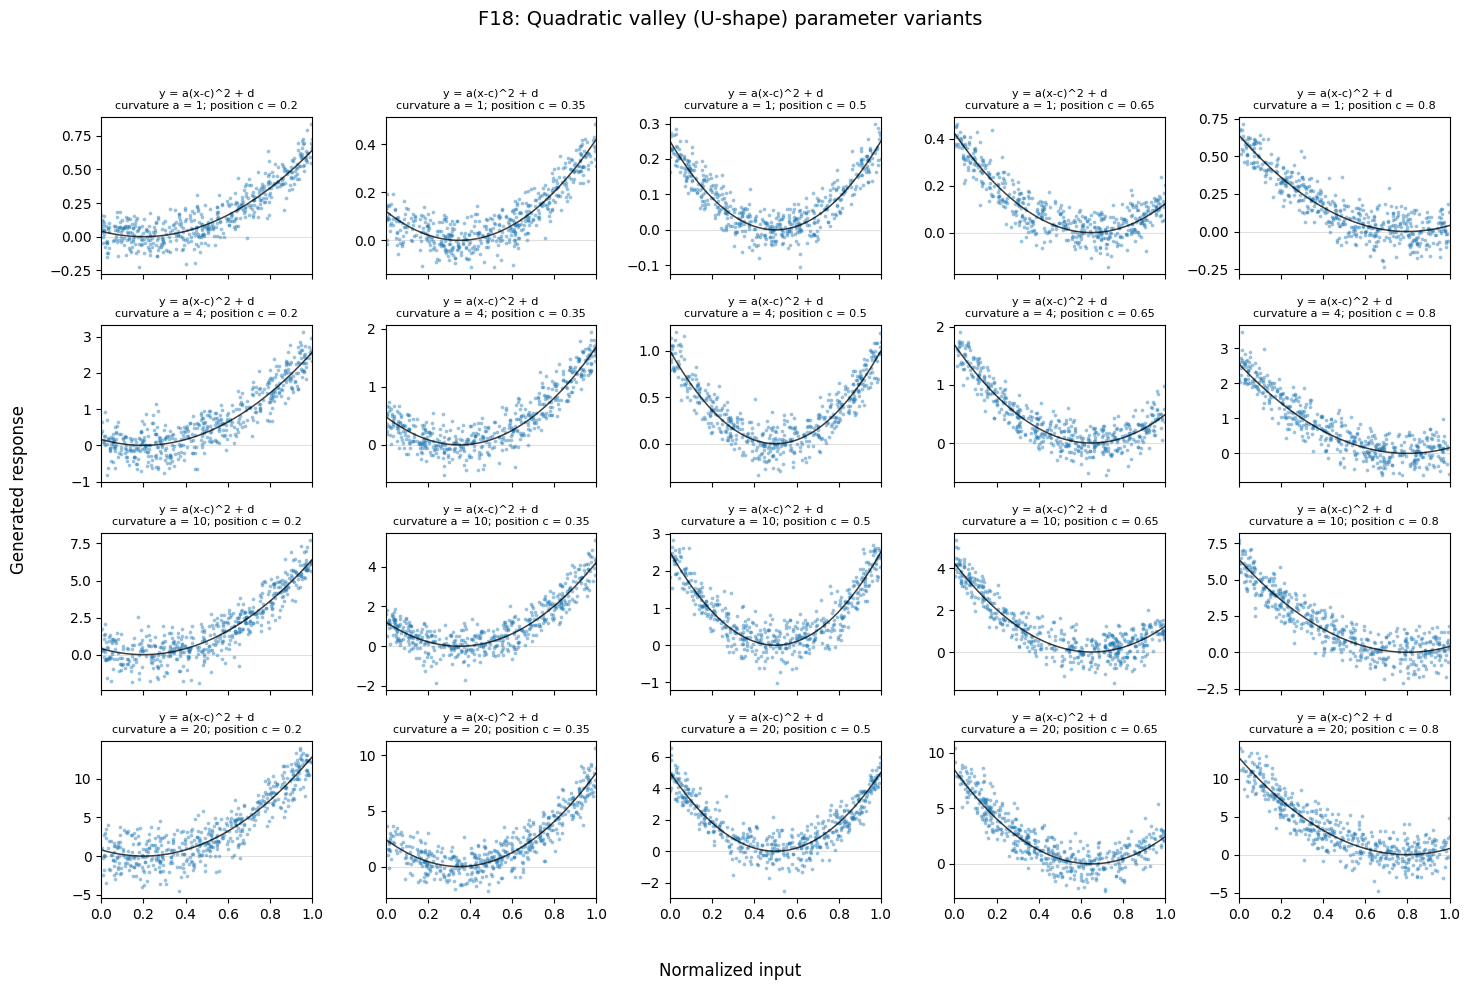

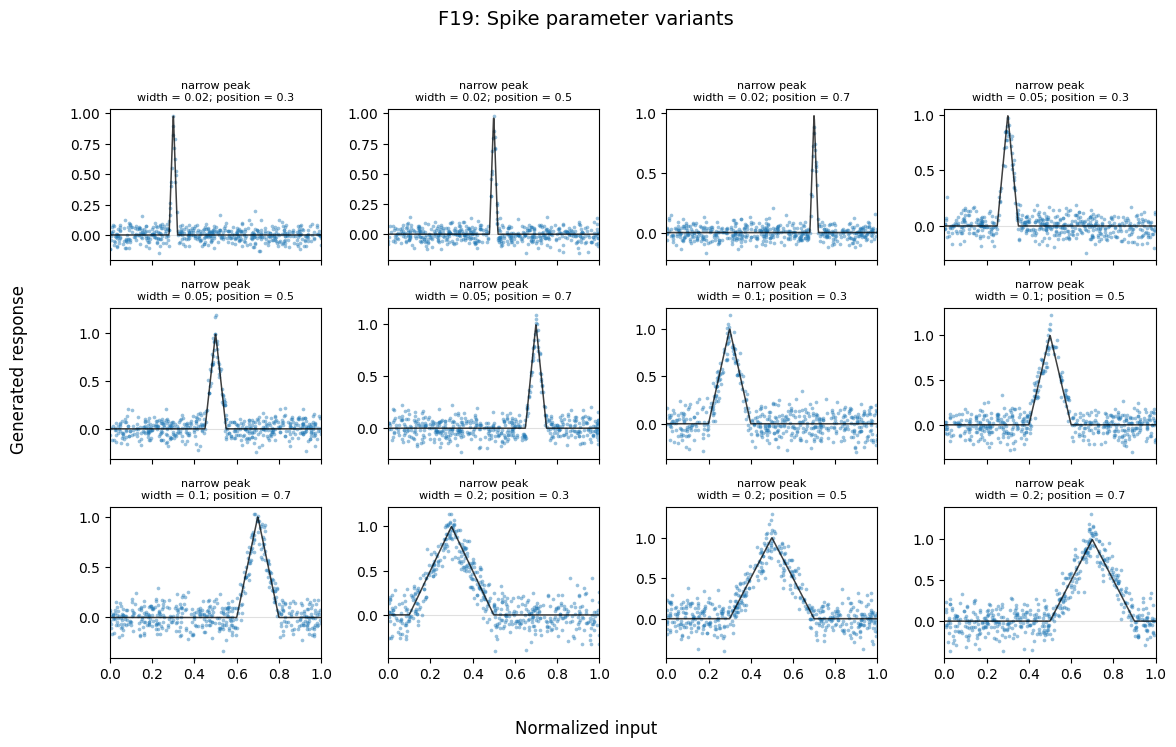

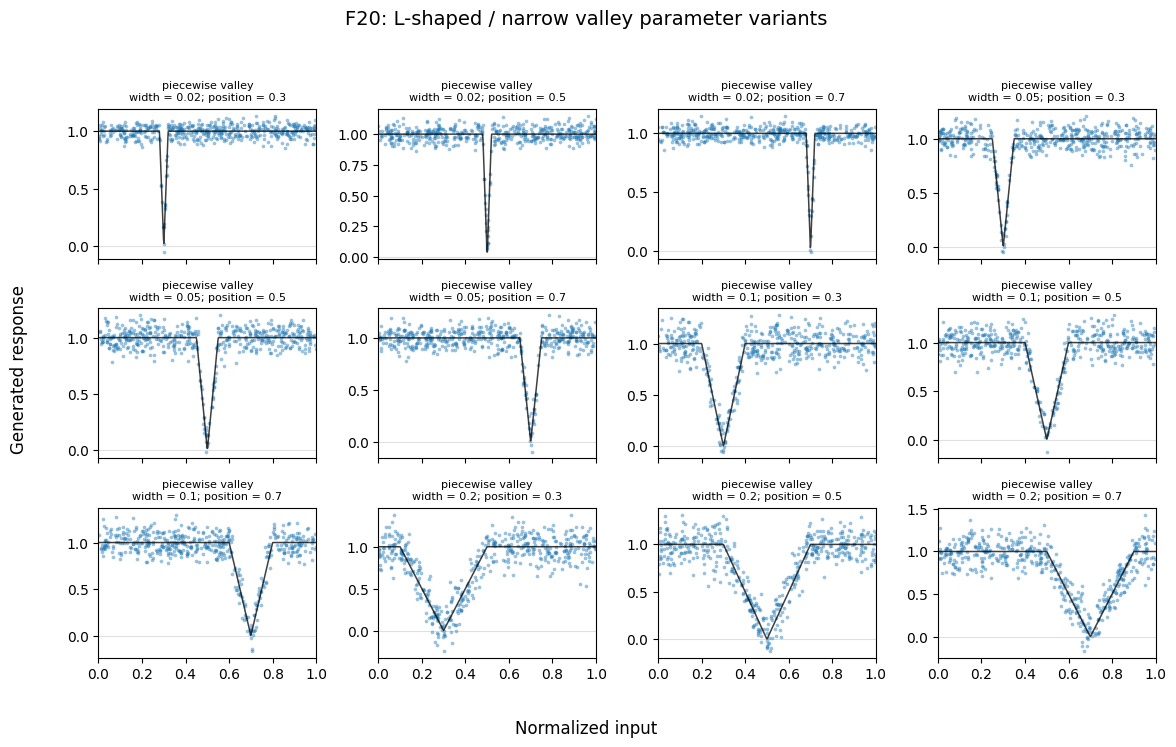

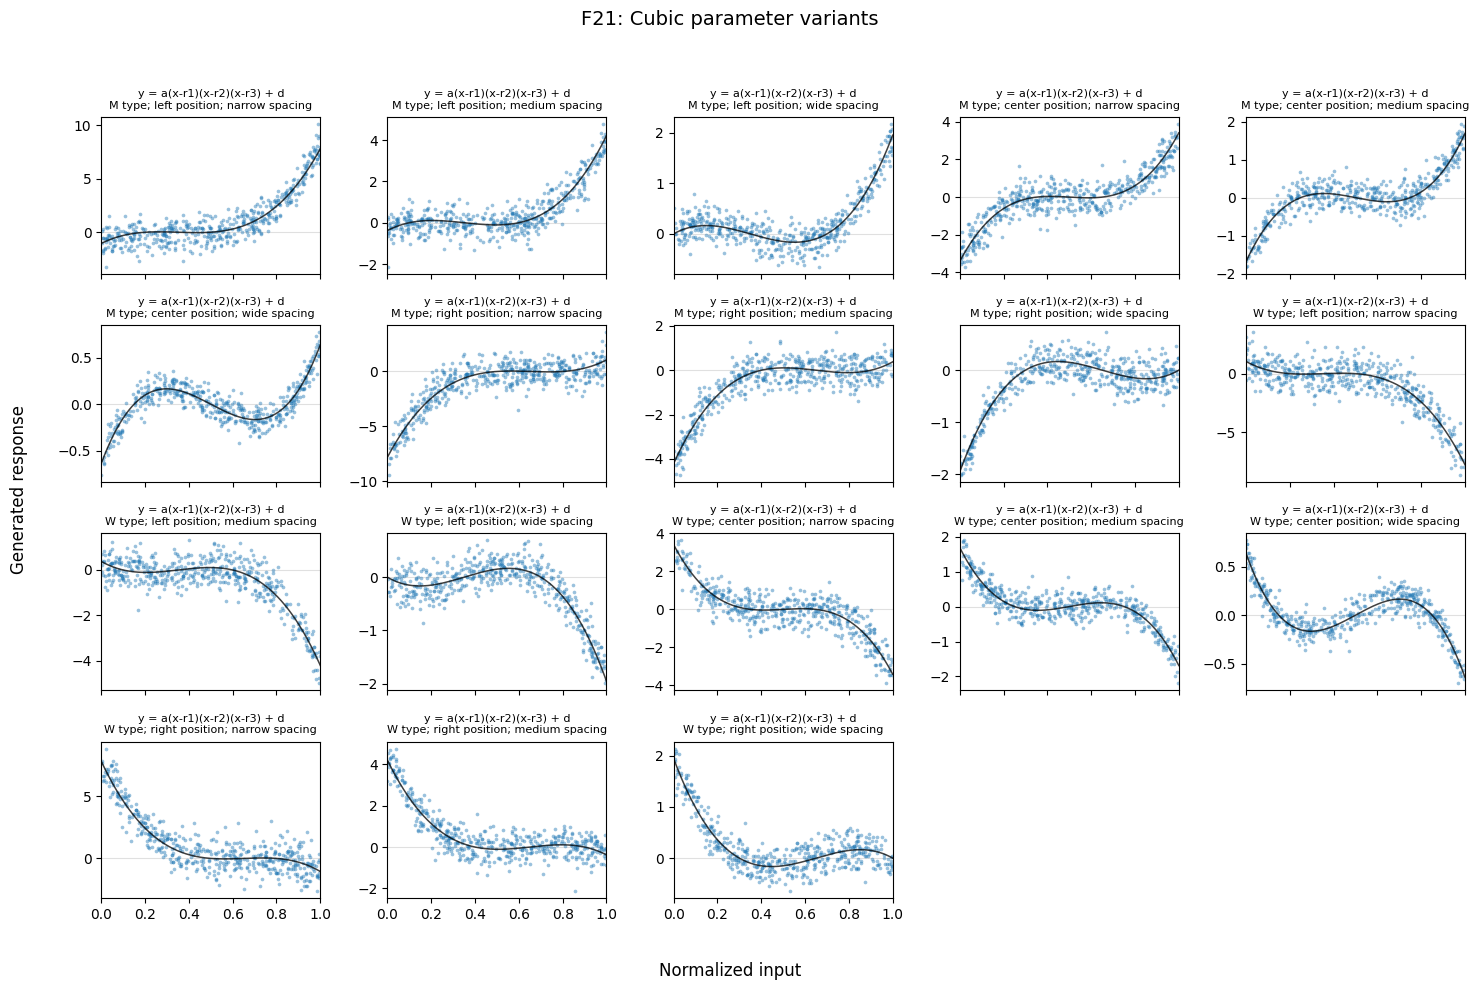

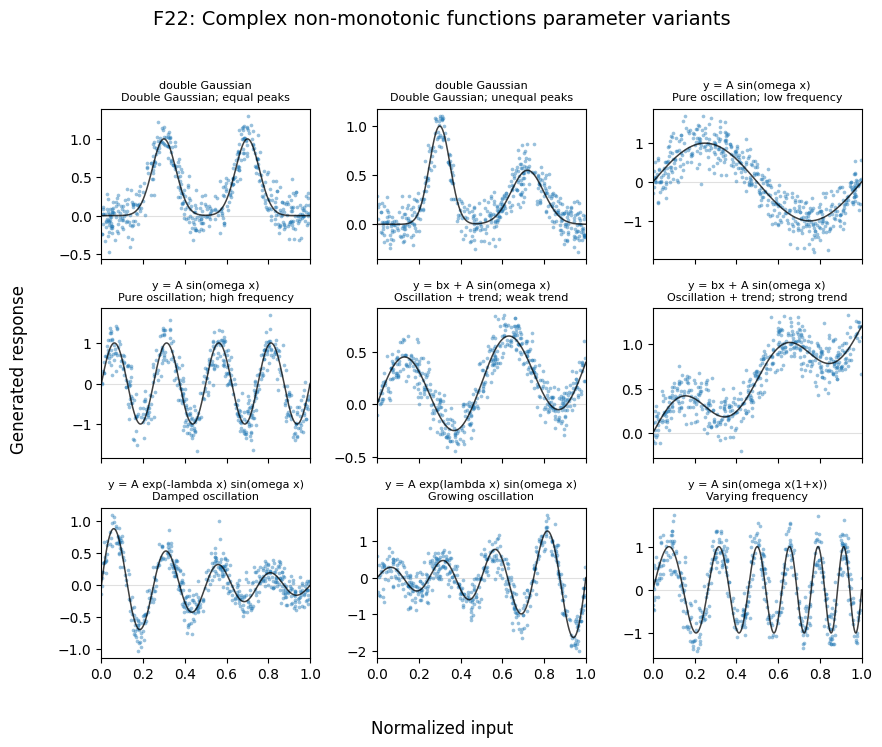

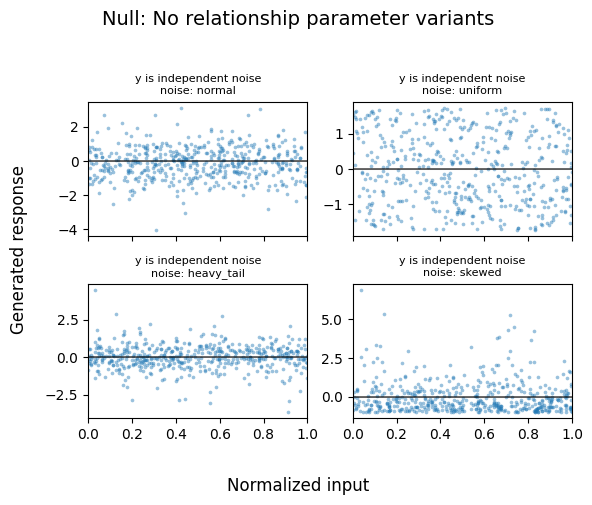

In [26]:
def _configs_for_family(family_id: str) -> list[ShapeConfig]:
    return [cfg for cfg in shape_configs if cfg.family_id == family_id]


def _format_value(value: Any) -> str:
    if isinstance(value, float):
        return f"{value:g}"
    return str(value)


def _variant_formula(cfg: ShapeConfig) -> str:
    fid = cfg.family_id

    if fid in {"F13", "F14"}:
        return "logistic form"
    if fid in {"F15", "F16"}:
        return "piecewise state change"
    if fid == "F19":
        return "narrow peak"
    if fid == "F20":
        return "piecewise valley"
    if fid == "F21":
        return "y = a(x-r1)(x-r2)(x-r3) + d"
    if fid == "F22":
        formulas = {
            "double_gaussian_equal": "double Gaussian",
            "double_gaussian_unequal": "double Gaussian",
            "pure_osc_low": "y = A sin(omega x)",
            "pure_osc_high": "y = A sin(omega x)",
            "oscillation_trend_weak": "y = bx + A sin(omega x)",
            "oscillation_trend_strong": "y = bx + A sin(omega x)",
            "damped_oscillation": "y = A exp(-lambda x) sin(omega x)",
            "growing_oscillation": "y = A exp(lambda x) sin(omega x)",
            "varying_frequency": "y = A sin(omega x(1+x))",
        }
        return formulas[cfg.variant_name]
    if fid == "Null":
        return "y is independent noise"
    return cfg.labels["equation_presentation"]


def _variant_subtitle(cfg: ShapeConfig) -> str:
    p = cfg.params
    fid = cfg.family_id

    if fid in {"F01", "F02"}:
        return f"slope a = {_format_value(p['slope'])}"
    if fid in {"F03", "F04", "F05", "F06"}:
        return f"exponent p = {_format_value(p['p'])}"
    if fid in {"F07", "F08"}:
        return f"rate k = {_format_value(p['k'])}"
    if fid in {"F09", "F10"}:
        return f"scale a = {_format_value(p['a'])}"
    if fid in {"F11", "F12"}:
        return f"base a = {_format_value(p['base'])}; x range = {_format_value(p['x_range'])}"
    if fid in {"F13", "F14"}:
        return f"steepness k = {_format_value(p['k'])}; center c = {_format_value(p['c'])}"
    if fid in {"F15", "F16"}:
        return f"gap = {_format_value(p['b'])}; width = {_format_value(p['delta'])}; position = {_format_value(p['c'])}"
    if fid in {"F17", "F18"}:
        return f"curvature a = {_format_value(p['a'])}; position c = {_format_value(p['c'])}"
    if fid in {"F19", "F20"}:
        return f"width = {_format_value(p['width'])}; position = {_format_value(p['c'])}"
    if fid == "F21":
        return f"{p['cubic_type']} type; {p['position']} position; {p['spacing']} spacing"
    if fid == "F22":
        readable_names = {
            "double_gaussian_equal": "Double Gaussian; equal peaks",
            "double_gaussian_unequal": "Double Gaussian; unequal peaks",
            "pure_osc_low": "Pure oscillation; low frequency",
            "pure_osc_high": "Pure oscillation; high frequency",
            "oscillation_trend_weak": "Oscillation + trend; weak trend",
            "oscillation_trend_strong": "Oscillation + trend; strong trend",
            "damped_oscillation": "Damped oscillation",
            "growing_oscillation": "Growing oscillation",
            "varying_frequency": "Varying frequency",
        }
        return readable_names[cfg.variant_name]
    if fid == "Null":
        dist_name = p.get("noise_dist", "normal")
        return f"noise: {dist_name}"
    return cfg.variant_name.replace("_", " ")


def _plot_variant_panel(
    ax: Any,
    cfg: ShapeConfig,
    rng: np.random.Generator,
    x_grid: np.ndarray,
    snr: float = 5,
    n: int = N_PER_CASE,
) -> None:
    x_points = rng.uniform(0.0, 1.0, size=n)
    y_signal_points = evaluate_signal(x_points, cfg)
    y_grid = evaluate_signal(x_grid, cfg)

    if cfg.family_id == "Null":
        noise_dist = cfg.params.get("noise_dist", "normal")
        if noise_dist == "normal":
            y_points = rng.normal(0.0, 1.0, size=n)
        elif noise_dist == "uniform":
            y_points = rng.uniform(-1.0, 1.0, size=n) * np.sqrt(3.0)
        elif noise_dist == "heavy_tail":
            y_points = rng.standard_t(df=3, size=n) / np.sqrt(3.0)
        elif noise_dist == "skewed":
            y_points = rng.exponential(1.0, size=n) - 1.0
        else:
            raise ValueError(f"Unknown noise distribution: {noise_dist}")
    else:
        sigma0 = sigma0_for_snr(cfg, snr)
        y_points = y_signal_points + rng.normal(0.0, sigma0, size=n)

    ax.scatter(x_points, y_points, s=7, alpha=0.45, linewidths=0)
    ax.plot(x_grid, y_grid, color="black", lw=1.1, alpha=0.75)
    ax.axhline(0, color="0.88", lw=0.8, zorder=0)
    ax.set_title(f"{_variant_formula(cfg)}\n{_variant_subtitle(cfg)}", fontsize=8)
    ax.set_xlim(0, 1)


def plot_family_variant_scatterplots(
    family_id: str,
    snr: float = 5,
    n: int = N_PER_CASE,
    seed: int = 20260617,
) -> None:
    configs = _configs_for_family(family_id)
    if not configs:
        raise LookupError(f"No configs found for family_id={family_id}")

    n_panels = len(configs)
    ncols = 1 if n_panels == 1 else min(6, max(2, math.ceil(math.sqrt(n_panels))))
    nrows = math.ceil(n_panels / ncols)
    fig_width = max(5, 3.0 * ncols)
    fig_height = max(3.2, 2.5 * nrows)
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_width, fig_height), sharex=True)
    axes = np.atleast_1d(axes).ravel()

    rng = np.random.default_rng(seed + sum(ord(ch) for ch in family_id))
    x_grid = np.linspace(0.0, 1.0, 600)
    for ax, cfg in zip(axes, configs):
        _plot_variant_panel(ax, cfg, rng, x_grid, snr=snr, n=n)

    for ax in axes[n_panels:]:
        ax.axis("off")

    family_name = FAMILY_LABELS[family_id]["family_name"]
    fig.suptitle(f"{family_id}: {family_name} parameter variants", fontsize=14)
    fig.supxlabel("Normalized input")
    fig.supylabel("Generated response")
    plt.tight_layout(rect=(0.02, 0.02, 1, 0.95))
    plt.show()


family_variant_plot_order = [f"F{i:02d}" for i in range(1, 23)] + ["Null"]

for family_id in family_variant_plot_order:
    plot_family_variant_scatterplots(family_id)

## Noise Model Demonstration (旋钮 2)

Using **F07 Saturation positive (k = 10)** as the example function to illustrate:

1. **旋钮 2a — SNR**: how signal-to-noise ratio controls noise magnitude (constant spread, uniform x)
2. **旋钮 2b — Spread multiplier functions**: the four σ(x)/σ₀ curves that shape noise heteroscedasticity
3. **旋钮 2b — Heteroscedasticity effect**: how different spread patterns alter the scatterplot at fixed SNR = 5

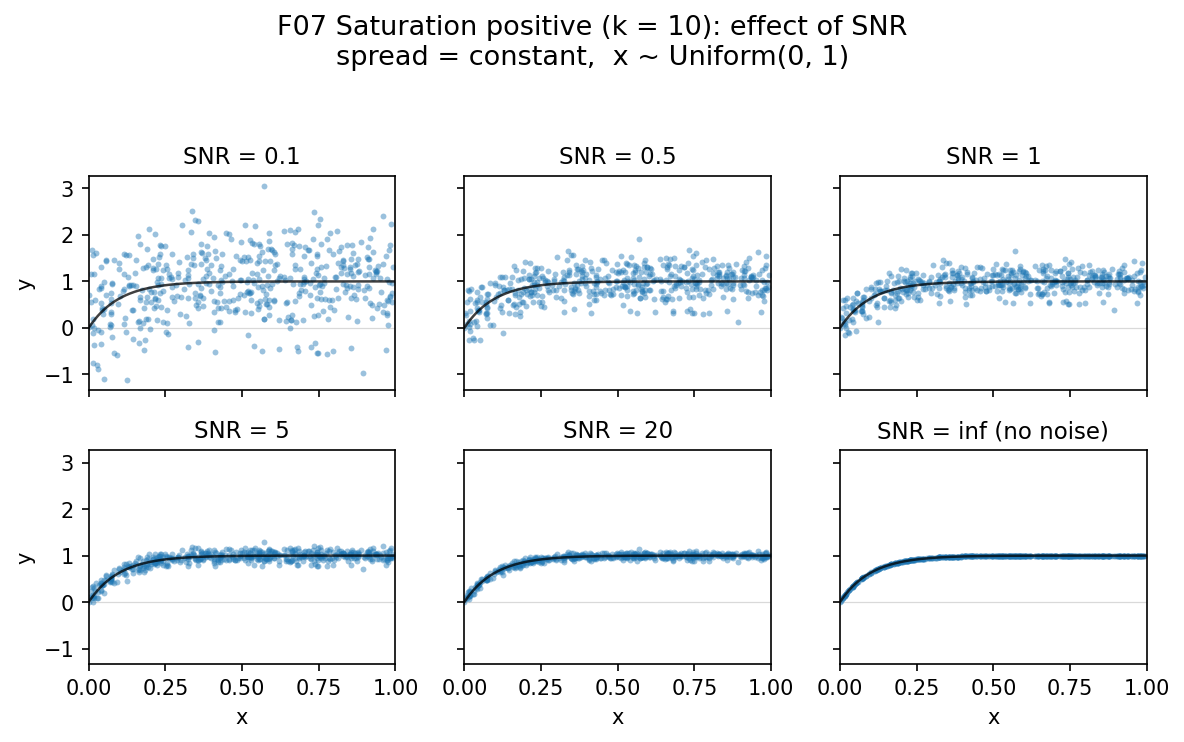

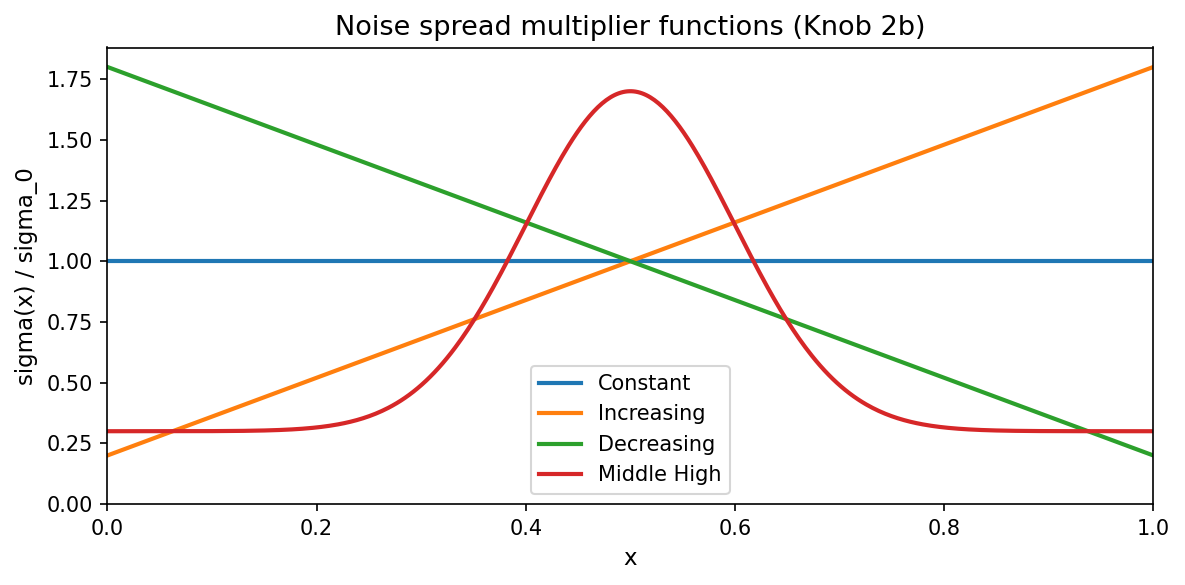

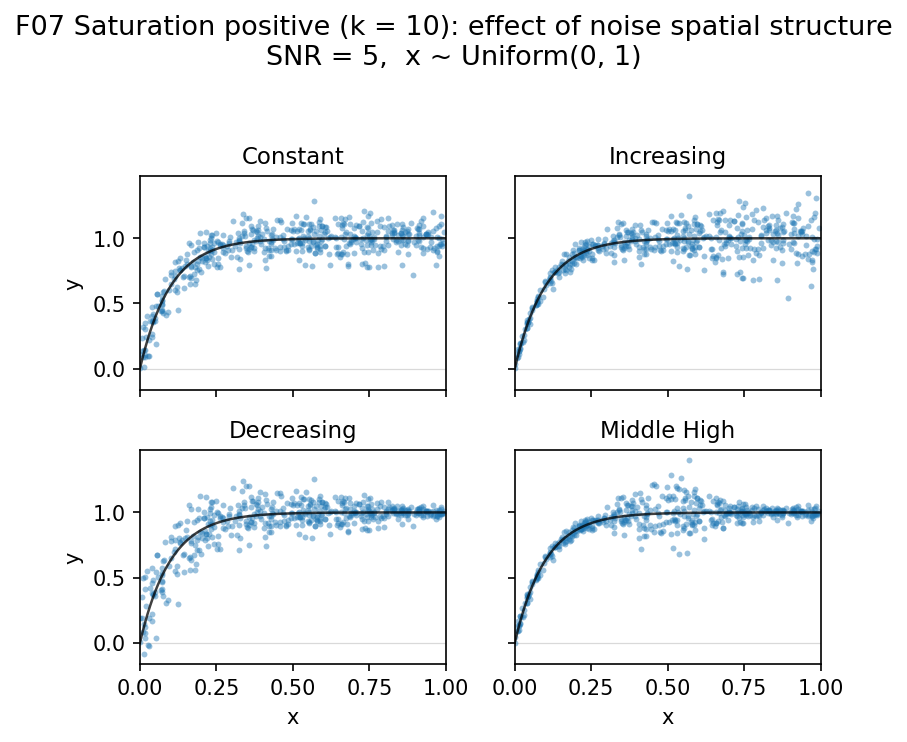

In [27]:
sat_cfg = _first_config("F07", "k_10")
x_grid_fine = np.linspace(0.0, 1.0, 600)
y_grid_fine = evaluate_signal(x_grid_fine, sat_cfg)

# ── Figure 1: SNR effect (Knob 2a) ─────────────────────────────────────────
snr_demo = [0.1, 0.5, 1, 5, 20, math.inf]
fig, axes = plt.subplots(2, 3, figsize=(8, 5), sharex=True, sharey=True, dpi=150)
fig.suptitle(
    "F07 Saturation positive (k = 10): effect of SNR\n"
    "spread = constant,  x ~ Uniform(0, 1)",
    fontsize=13,
)

for ax, snr in zip(axes.flat, snr_demo):
    rng = np.random.default_rng(20260617)
    x_pts = rng.uniform(0, 1, size=N_PER_CASE)
    y_sig = evaluate_signal(x_pts, sat_cfg)
    s0 = sigma0_for_snr(sat_cfg, snr)
    y_pts = y_sig + rng.normal(0, s0, size=N_PER_CASE)

    ax.scatter(x_pts, y_pts, s=8, alpha=0.45, linewidths=0)
    ax.plot(x_grid_fine, y_grid_fine, color="black", lw=1.2, alpha=0.75)
    ax.axhline(0, color="0.85", lw=0.6, zorder=0)
    snr_label = "inf (no noise)" if math.isinf(snr) else f"{snr}"
    ax.set_title(f"SNR = {snr_label}", fontsize=11)
    ax.set_xlim(0, 1)

for ax in axes[-1]:
    ax.set_xlabel("x")
for ax in axes[:, 0]:
    ax.set_ylabel("y")
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()


# ── Figure 2: Spread multiplier functions ───────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
x_line = np.linspace(0, 1, 500)
for pattern in SPREAD_PATTERNS:
    label = pattern.replace("_", " ").title()
    ax.plot(x_line, spread_multiplier(x_line, pattern), label=label, lw=2)
ax.set_xlabel("x", fontsize=11)
ax.set_ylabel("sigma(x) / sigma_0", fontsize=11)
ax.set_title("Noise spread multiplier functions (Knob 2b)", fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(0, 1)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()


# ── Figure 3: Heteroscedasticity effect on scatterplots (Knob 2b) ──────────
fig, axes = plt.subplots(2, 2, figsize=(5.5, 5), sharex=True, sharey=True, dpi=150)
fig.suptitle(
    "F07 Saturation positive (k = 10): effect of noise spatial structure\n"
    "SNR = 5,  x ~ Uniform(0, 1)",
    fontsize=13,
)

for ax, pattern in zip(axes.flat, SPREAD_PATTERNS):
    rng = np.random.default_rng(20260617)
    x_pts = rng.uniform(0, 1, size=N_PER_CASE)
    y_sig = evaluate_signal(x_pts, sat_cfg)
    s0 = sigma0_for_snr(sat_cfg, 5)
    sigma_i = s0 * spread_multiplier(x_pts, pattern)
    y_pts = y_sig + rng.standard_normal(size=N_PER_CASE) * sigma_i

    ax.scatter(x_pts, y_pts, s=8, alpha=0.45, linewidths=0)
    ax.plot(x_grid_fine, y_grid_fine, color="black", lw=1.2, alpha=0.75)
    ax.axhline(0, color="0.85", lw=0.6, zorder=0)
    ax.set_title(pattern.replace("_", " ").title(), fontsize=11)
    ax.set_xlim(0, 1)

for ax in axes[-1]:
    ax.set_xlabel("x")
for ax in axes[:, 0]:
    ax.set_ylabel("y")
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

## Sampling Distribution Demonstration (Knob 3)

Using **F07 Saturation positive (k = 3)** as the example function to illustrate:

1. **x sampling density profiles**: histogram of x samples for each distribution (even, 3 uneven density, 4 cluster configurations)
2. **Effect on scatterplots**: how different x distributions change the scatterplot appearance at fixed SNR = 5, constant spread

Note: k = 3 (instead of k = 10) is chosen here so the saturation curve has meaningful curvature throughout [0, 1], making the effect of different sampling distributions clearly visible.

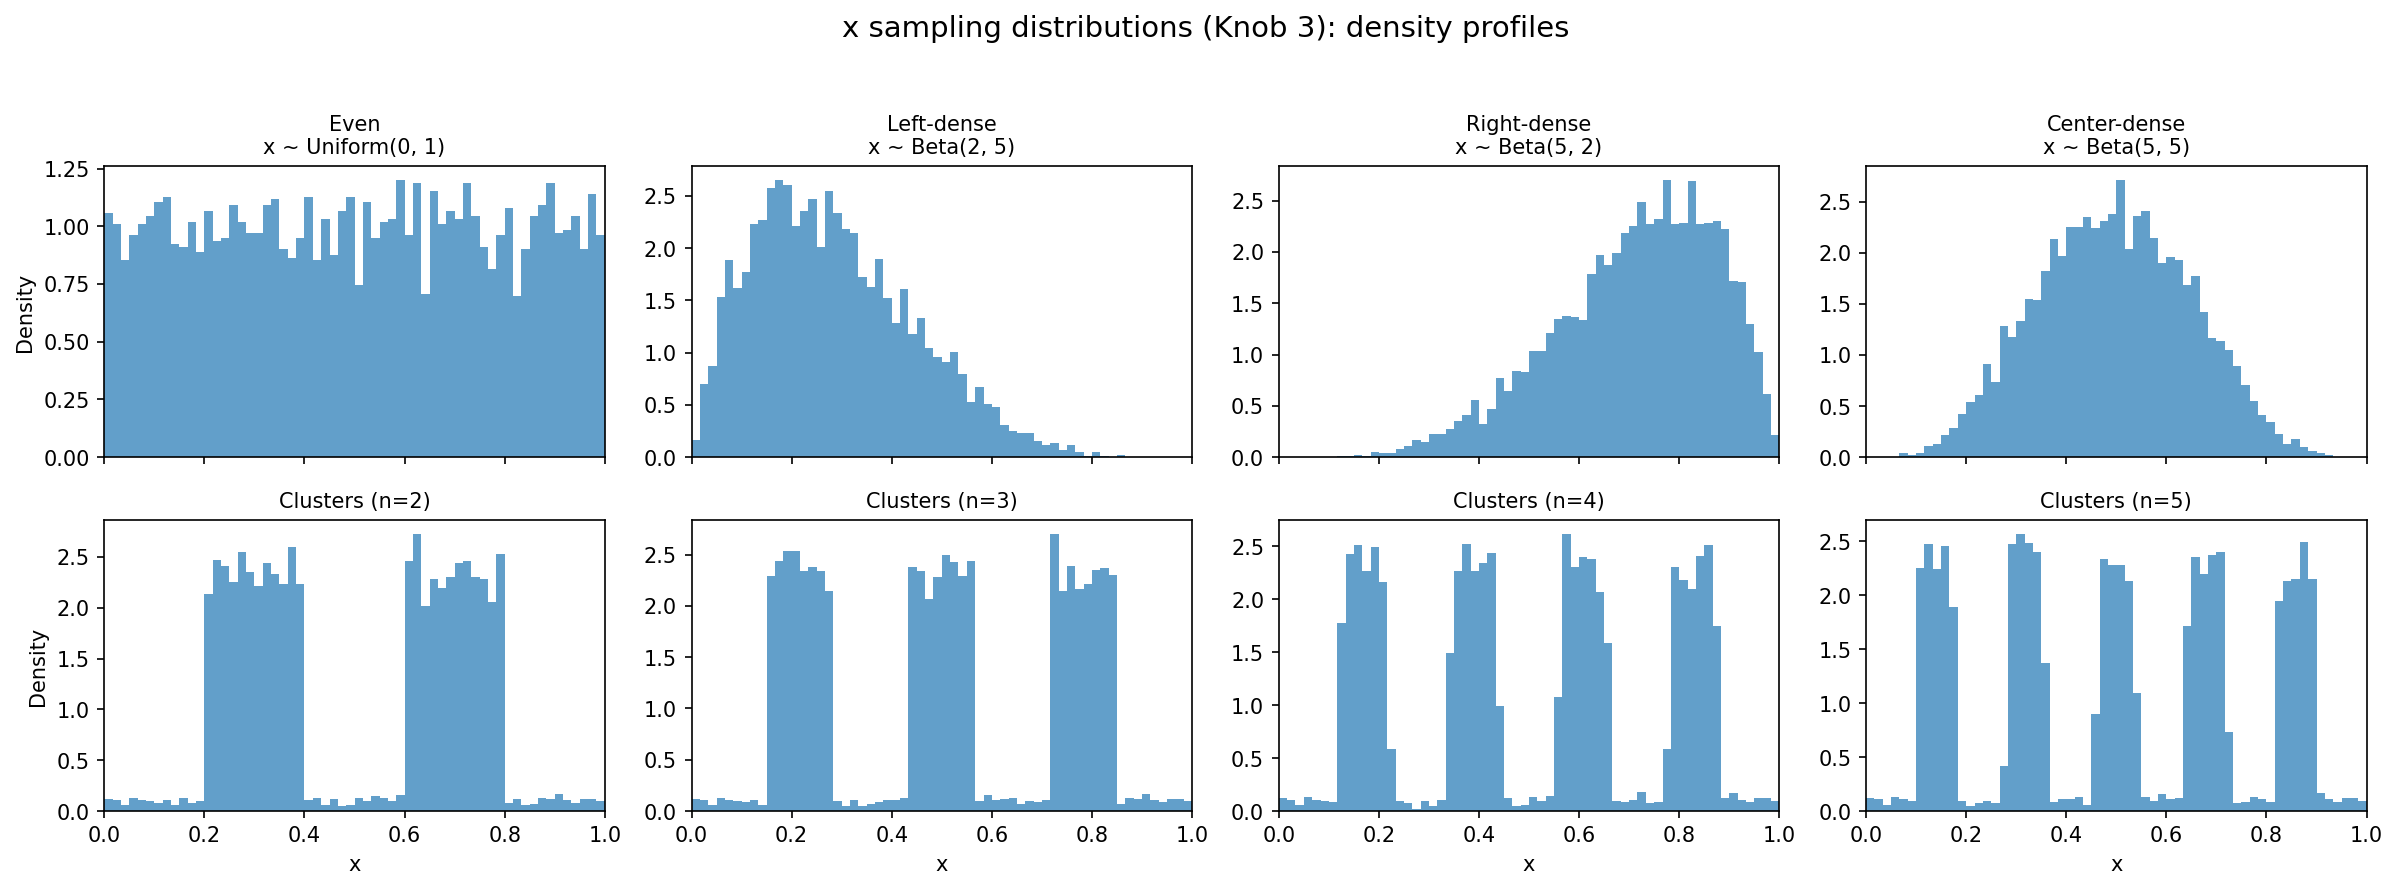

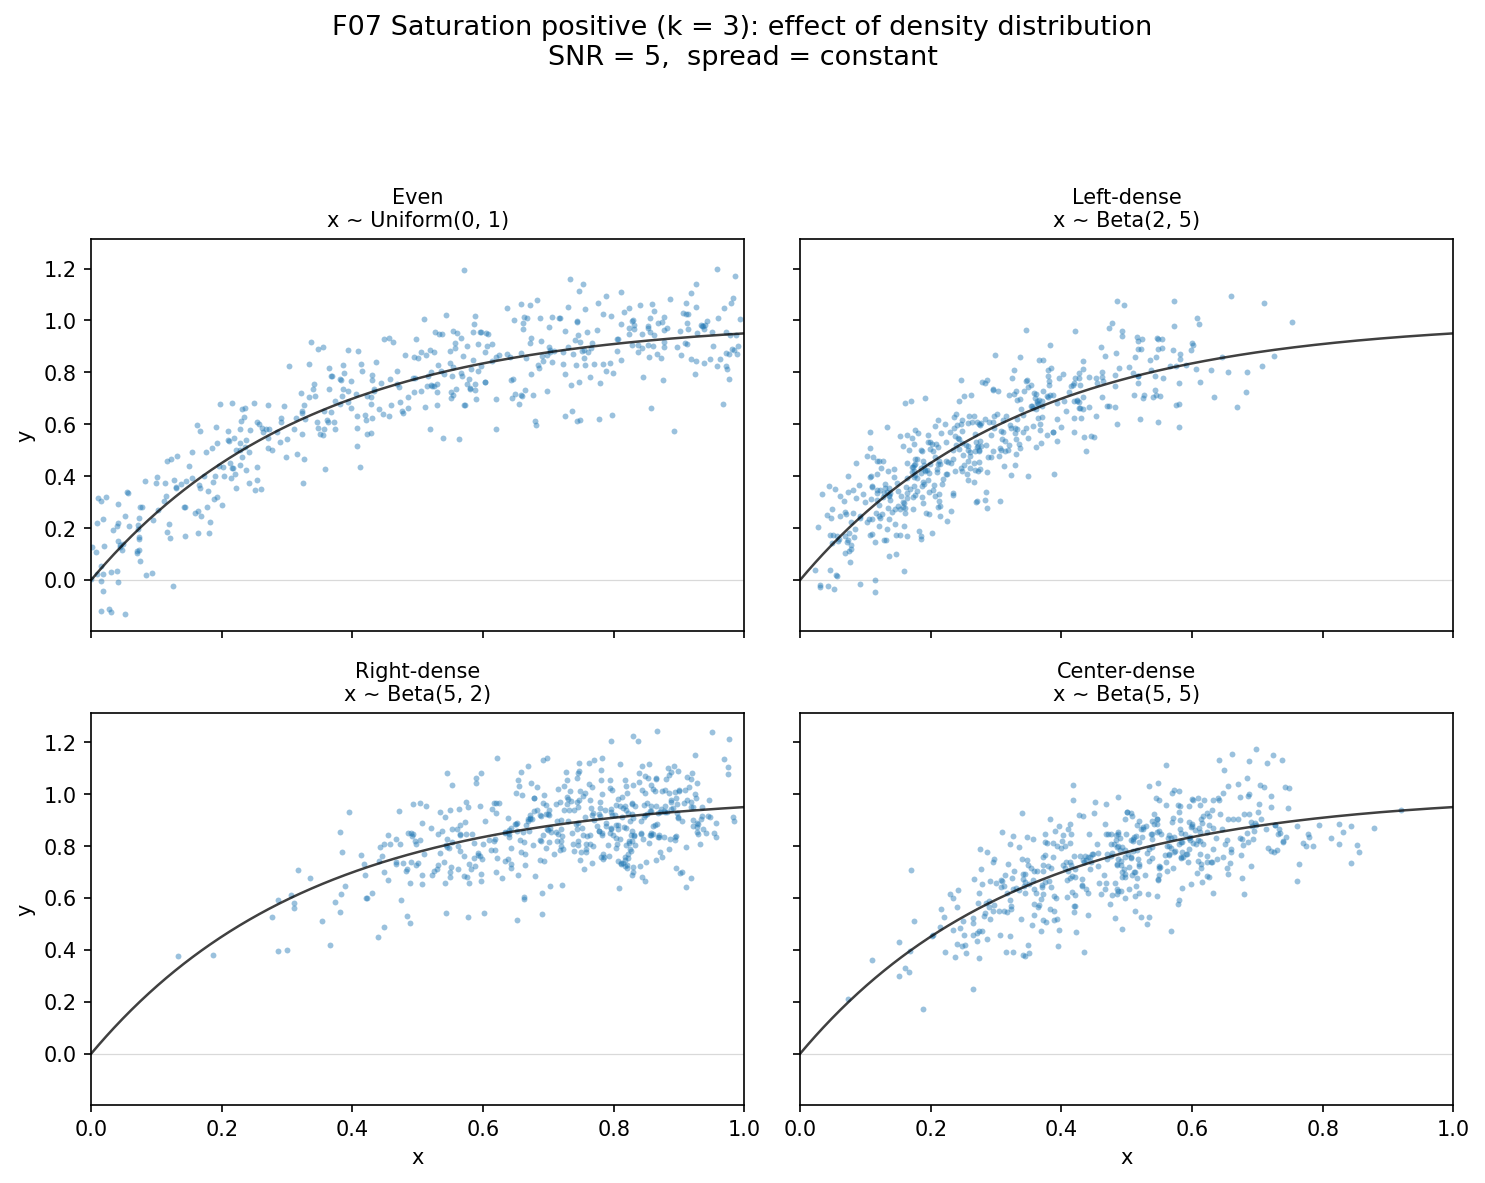

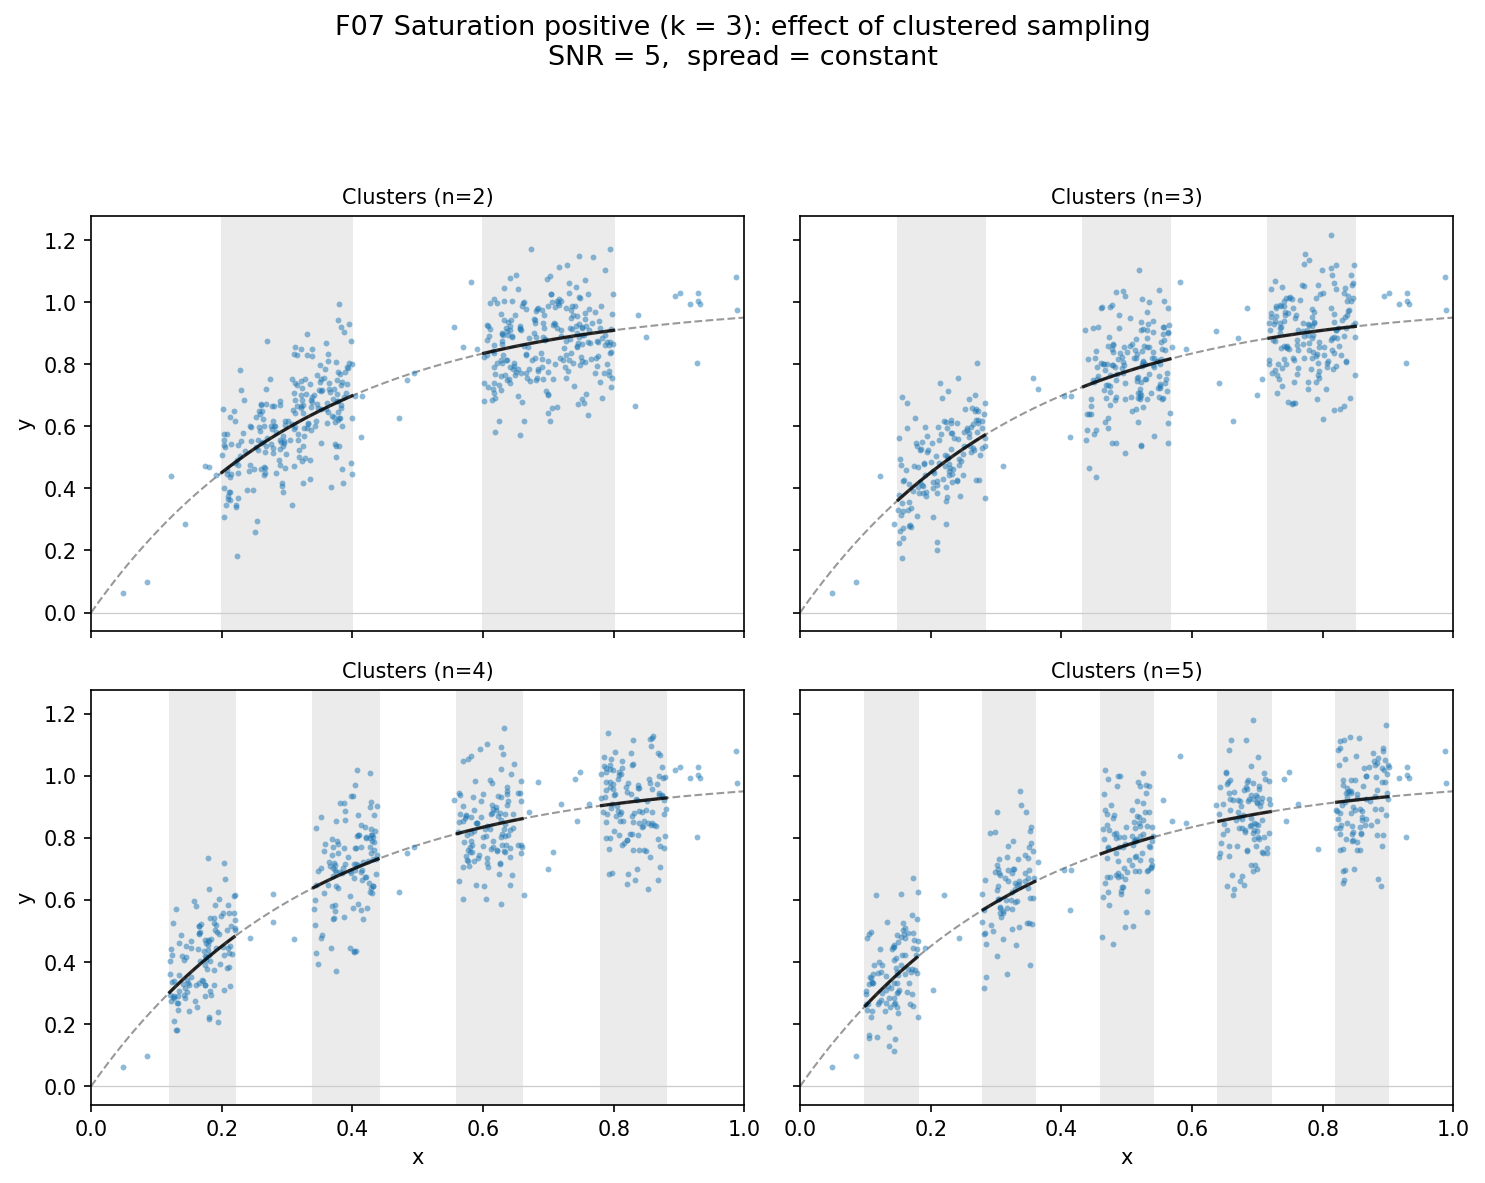

In [28]:
sat_cfg_k3 = _first_config("F07", "k_3")
x_grid_k3 = np.linspace(0.0, 1.0, 600)
y_grid_k3 = evaluate_signal(x_grid_k3, sat_cfg_k3)

density_dists = ["even", "left_dense", "right_dense", "center_dense"]
cluster_dists = [f"clusters_{k}" for k in N_CLUSTERS_VALUES]
all_dists = density_dists + cluster_dists

dist_labels = {
    "even": "Even\nx ~ Uniform(0, 1)",
    "left_dense": "Left-dense\nx ~ Beta(2, 5)",
    "right_dense": "Right-dense\nx ~ Beta(5, 2)",
    "center_dense": "Center-dense\nx ~ Beta(5, 5)",
    "clusters_2": "Clusters (n=2)",
    "clusters_3": "Clusters (n=3)",
    "clusters_4": "Clusters (n=4)",
    "clusters_5": "Clusters (n=5)",
}


# ── Figure 1: x sampling density profiles (2×4) ───────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharex=True, dpi=150)
fig.suptitle("x sampling distributions (Knob 3): density profiles", fontsize=14)

for ax, dist_name in zip(axes.flat, all_dists):
    rng = np.random.default_rng(20260617)
    x_samples = sample_x(5000, dist_name, rng)
    ax.hist(x_samples, bins=60, range=(0, 1), density=True, alpha=0.7, edgecolor="none")
    ax.set_title(dist_labels[dist_name], fontsize=10)
    ax.set_xlim(0, 1)
    ax.set_ylim(bottom=0)

for ax in axes[-1]:
    ax.set_xlabel("x")
for ax in axes[:, 0]:
    ax.set_ylabel("Density")
plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()


# ── Figure 2: Density distributions effect on scatterplots (2×2) ───────────
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True, dpi=150)
fig.suptitle(
    "F07 Saturation positive (k = 3): effect of density distribution\n"
    "SNR = 5,  spread = constant",
    fontsize=13,
)

s0_k3 = sigma0_for_snr(sat_cfg_k3, 5)
for ax, dist_name in zip(axes.flat, density_dists):
    rng = np.random.default_rng(20260617)
    x_pts = sample_x(N_PER_CASE, dist_name, rng)
    y_sig = evaluate_signal(x_pts, sat_cfg_k3)
    y_pts = y_sig + rng.normal(0, s0_k3, size=N_PER_CASE)

    ax.scatter(x_pts, y_pts, s=8, alpha=0.45, linewidths=0)
    ax.plot(x_grid_k3, y_grid_k3, color="black", lw=1.2, alpha=0.75)
    ax.axhline(0, color="0.85", lw=0.6, zorder=0)
    ax.set_title(dist_labels[dist_name], fontsize=10)
    ax.set_xlim(0, 1)

for ax in axes[-1]:
    ax.set_xlabel("x")
for ax in axes[:, 0]:
    ax.set_ylabel("y")
plt.tight_layout(rect=(0, 0, 1, 0.92))
plt.show()


# ── Figure 3: Cluster distributions effect on scatterplots (2×2) ───────────
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True, dpi=150)
fig.suptitle(
    "F07 Saturation positive (k = 3): effect of clustered sampling\n"
    "SNR = 5,  spread = constant",
    fontsize=13,
)

for ax, dist_name in zip(axes.flat, cluster_dists):
    n_cl = int(dist_name.split("_")[1])
    bounds = _cluster_bounds(n_cl)

    rng = np.random.default_rng(20260617)
    x_pts = sample_x(N_PER_CASE, dist_name, rng)
    y_sig = evaluate_signal(x_pts, sat_cfg_k3)
    y_pts = y_sig + rng.normal(0, s0_k3, size=N_PER_CASE)

    for lo, hi in bounds:
        ax.axvspan(lo, hi, color="0.92", zorder=0)

    ax.scatter(x_pts, y_pts, s=8, alpha=0.5, linewidths=0, zorder=2)
    ax.plot(x_grid_k3, y_grid_k3, color="black", lw=1.0, ls="--", alpha=0.4, zorder=1)
    for lo, hi in bounds:
        mask = (x_grid_k3 >= lo) & (x_grid_k3 <= hi)
        ax.plot(x_grid_k3[mask], y_grid_k3[mask], color="black", lw=1.6, alpha=0.8, zorder=3)

    ax.axhline(0, color="0.80", lw=0.6, zorder=0)
    ax.set_title(dist_labels[dist_name], fontsize=10)
    ax.set_xlim(0, 1)

for ax in axes[-1]:
    ax.set_xlabel("x")
for ax in axes[:, 0]:
    ax.set_ylabel("y")
plt.tight_layout(rect=(0, 0, 1, 0.92))
plt.show()
